# S3. Qualitative comparison — 96 µm vs 128 µm

What the two models actually produce, rather than how they score. Everything reads from
**featurized AnnData** written by TissueMosaic's own `main_2_featurize.py`, merged into
single scanpy-native objects so the standard plotting API applies.

Both models are read from featurized AnnData whose source checkpoint is recorded in
`_provenance.json` and printed below — currently the **epoch-574** checkpoints — the highest epoch both configs share,
so the comparison is at matched training rather than at whatever each happened to reach.

**These runs did not finish.** They were launched for 1000 epochs but the driver was
killed at ~14 h, leaving fov96 at epoch 600 and fov128 at 579. The LR was therefore
still on its peak plateau throughout: the cosine decay that consolidates a DINO
representation runs epochs 900–1000 and never happened. Read everything here as a
mid-plateau snapshot of an unconverged model.

### The merged objects

`main_2_featurize` writes one file per ROI with the window data buried in
`uns['sparse_image_state_dict']['patch_properties_dict']`. `anndata.concat` on those
would merge the *cells* and discard it — the wrong axis, since the things we cluster and
plot are windows. `imc_tm.merge_featurized` pivots the axis instead:

| | `windows` (one obs per window) | `cells` (one obs per cell) |
|---|---|---|
| `X` | 512-d embedding | cell-type one-hot |
| `obs` | roi, patient, status, x, y, fov_um, `frac_*` | roi, patient, cell_type, x, y |
| `obsm['spatial']` | window centre | cell position |
| `obsm['composition']` | the library's own `patch_ncv` | — |

Both are put in the **same raster frame**, so they overlay. That matters: `patch_xywh`
is in raster pixels from the padded origin while the source `obs['x']` is microns
centred on the ROI, and plotting them together untransformed misaligns the panels
silently.

### Colour convention

The two cluster sets take **disjoint** slices of `glasbey_dark` — 96 µm the even
indices, 128 µm the odd — so cluster 3 of one is never the colour of cluster 3 of the
other. Cell types keep their usual palette, which reuses some of those hues; that
overlap is across panels showing different things, and far less confusable than two
cluster sets sharing colours.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# resolve imc_tm from anywhere: repo root, tissuemosaic/, notebooks/, notebooks/archive/
_cands = [c for p in [Path.cwd(), *Path.cwd().parents] for c in (p, p / "tissuemosaic")]
sys.path.insert(0, str(next(c for c in _cands if (c / "imc_tm.py").exists())))
import importlib
import imc_tm

# RE-RUNNING THIS CELL IS NOT ENOUGH ON ITS OWN. Python caches modules in sys.modules,
# so `import imc_tm` in a kernel that already has it is a no-op and you keep whatever
# version was loaded first -- edits to imc_tm.py are silently ignored until the kernel
# restarts. That produced figures with a stale colour palette that looked fine.
importlib.reload(imc_tm)

import numpy as np, pandas as pd, anndata as ad, scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
import warnings

warnings.filterwarnings("ignore")
sc.settings.verbosity = 0
pd.set_option("display.width", 250)

CONFIGS = {"fov96": 96, "fov128": 128}
STRIDE = {"fov96": 0, "fov128": 1}  # even / odd glasbey slices, disjoint
N_NEIGHBORS, RESOLUTION, SEED = 30, 1.0, 0

print(imc_tm.compat_summary())

# --- which checkpoint produced this data? ------------------------------------
# S3 reads featurized h5ad, not checkpoints, so the training epoch is otherwise
# invisible here. run_featurize writes _provenance.json alongside; this reads it,
# refuses to run on a half-written folder, and refuses to compare two configs
# featurized from DIFFERENT epochs (which would confound FOV with training length).
import json

PROV = {}
for k in CONFIGS:
    f = imc_tm.REPO / "tissuemosaic" / f"imc_anndata_feat_{k}" / "_provenance.json"
    if not f.is_file():
        raise FileNotFoundError(
            f"{f} missing. Re-run the featurisation -- and note it rm -rf's the folder, "
            f"so this notebook fails if run while that is in progress."
        )
    PROV[k] = json.loads(f.read_text())
    print(
        f"  {k:<7s} epoch {PROV[k]['epoch']:<5d} {PROV[k]['n_h5ad']} h5ad  "
        f"featurized {PROV[k]['featurized_at']}"
    )
EPOCHS = {PROV[k]["epoch"] for k in CONFIGS}
assert len(EPOCHS) == 1, (
    f"configs featurized from DIFFERENT epochs {EPOCHS} -- not comparable"
)
EPOCH = EPOCHS.pop()
for k in CONFIGS:
    n = len(
        list((imc_tm.REPO / "tissuemosaic" / f"imc_anndata_feat_{k}").glob("*.h5ad"))
    )
    assert n == PROV[k]["n_h5ad"] == len(imc_tm.FINAL_ROIS), (
        f"{k}: {n} h5ad on disk vs {PROV[k]['n_h5ad']} recorded -- folder is mid-rebuild"
    )
print(f"  -> both configs at epoch {EPOCH}")

# Show the palette actually in force. If these are not greys the kernel is stale --
# restart it, or check that importlib.reload above ran.
_bg = {t: to_hex(imc_tm.palette()[t]) for t in imc_tm.BACKGROUND_TYPES}
print("background colours in force:", _bg)
assert _bg["other_tissue"].lower() == "#d8d8d8", (
    "STALE imc_tm: expected grey background, got {}. Restart the kernel.".format(_bg)
)

W, cells = {}, None
for k in CONFIGS:
    folder = imc_tm.REPO / "tissuemosaic" / f"imc_anndata_feat_{k}"
    W[k] = imc_tm.merge_featurized(folder)
    if cells is None:
        cells = imc_tm.merge_cells(folder)  # same for both; frame is per-ROI
    print(
        f"  {k:<7s} {W[k].n_obs:5d} windows x {W[k].n_vars} dims  "
        f"| {W[k].obs.roi.nunique()} ROIs, {W[k].obs.patient.nunique()} patients"
    )
print(f"  cells   {cells.n_obs:,} across {cells.obs.roi.nunique()} ROIs")
ROIS = list(W["fov128"].obs.roi.cat.categories)

tm_compat: 34 numpy types allowlisted (weights_only stays True); relaxed only for test_dataset.pt, train_dataset.pt
  fov96   epoch 574   8 h5ad  featurized 2026-08-21T14:32:47
  fov128  epoch 574   8 h5ad  featurized 2026-08-21T14:37:11
  -> both configs at epoch 574
background colours in force: {'other_tissue': '#d8d8d8', 'duct_filler': '#4a4a4a'}
  fov96    1052 windows x 512 dims  | 8 ROIs, 5 patients
  fov128    642 windows x 512 dims  | 8 ROIs, 5 patients
  cells   61,103 across 8 ROIs


### Windows per ROI

In [2]:
tab = pd.DataFrame({k: W[k].obs.groupby("roi", observed=True).size() for k in CONFIGS})
tab["patient"] = [
    W["fov128"].obs.loc[W["fov128"].obs.roi == r, "patient"].iloc[0] for r in tab.index
]
tab["cells"] = cells.obs.groupby("roi", observed=True).size()
display(tab[["patient", "cells"] + list(CONFIGS)])

,patient,cells,fov96,fov128
roi,,,,
JHH317ROI2,JHH317,2632,79,63
JHH357ROI5,JHH357,8920,143,84
JHH369ROI1,JHH369,8025,143,88
JHH369ROI2,JHH369,6383,144,89
JHH369ROI3,JHH369,7572,148,89
JHH369ROI4,JHH369,8724,144,81
JHH380ROI1,JHH380,8250,128,78
JHH387ROI1,JHH387,10597,123,70


### Proving the frames line up

For each ROI, take the densest window, count the cells falling inside its bounds under
the transform, and compare their composition to the `patch_ncv` the library stored for
that same window. Agreement means the overlay is right — checked, not assumed.

In [3]:
rows = []
for k in CONFIGS:
    w = W[k]
    for r in ROIS:
        ws = w[w.obs.roi == r]
        cs = cells[cells.obs.roi == r]
        half = float(ws.obs.fov_um.iloc[0]) / 2.0
        P, Q = ws.obsm["spatial"], cs.obsm["spatial"]
        inside = [
            (
                (Q[:, 0] >= c[0] - half)
                & (Q[:, 0] < c[0] + half)
                & (Q[:, 1] >= c[1] - half)
                & (Q[:, 1] < c[1] + half)
            )
            for c in P
        ]
        counts = np.array([m.sum() for m in inside])
        i = int(counts.argmax())
        mine = pd.Series(np.asarray(cs.obs.cell_type)[inside[i]]).value_counts(
            normalize=True
        )
        mine = np.array([mine.get(t, 0.0) for t in imc_tm.CELL_TYPES])
        rows.append(
            {
                "config": k,
                "roi": r,
                "cells_in_densest": int(counts.max()),
                "empty_windows": int((counts == 0).sum()),
                "max_diff_vs_patch_ncv": float(
                    np.abs(mine - ws.obsm["composition"][i]).max()
                ),
            }
        )
chk = pd.DataFrame(rows)
display(
    chk.pivot(
        index="roi",
        columns="config",
        values=["cells_in_densest", "max_diff_vs_patch_ncv"],
    )
)
worst = chk["max_diff_vs_patch_ncv"].max()
print(f"worst composition disagreement: {worst:.3f}")
print(
    "PASS -- frames aligned"
    if worst < 0.15
    else "FAIL -- panels would be misaligned; do not trust the tissue maps"
)

cells_in_densest        max_diff_vs_patch_ncv          
config               fov128  fov96                fov128     fov96
roi                                                               
JHH317ROI2            188.0  107.0          3.931545e-03  0.000000
JHH357ROI5            333.0  193.0          3.003003e-03  0.004869
JHH369ROI1            160.0  103.0          7.990506e-03  0.014843
JHH369ROI2            149.0   87.0          5.623073e-03  0.009404
JHH369ROI3            167.0  103.0          5.491975e-03  0.008229
JHH369ROI4            190.0  120.0          5.551115e-17  0.016667
JHH380ROI1            172.0  104.0          5.813953e-03  0.019136
JHH387ROI1            407.0  194.0          7.633169e-03  0.014189

worst composition disagreement: 0.019
PASS -- frames aligned


## Cluster

TissueMosaic's own `SmartPca → SmartUmap → Leiden-on-the-UMAP-graph`, written back into
each object as `obs['leiden']` and `obsm['X_umap']` so scanpy's plotting API applies
directly. Palettes go into `uns['leiden_colors']`, which is where scanpy looks.

(Not the tutorial's `n_neighbors=100, res=0.1–0.3` — that collapses this data to 1–2
clusters. See `imc_tm.cluster_embedding_tm`.)

In [4]:
for k in CONFIGS:
    w = W[k]
    cl = imc_tm.cluster_embedding_tm(
        w.X, n_neighbors=N_NEIGHBORS, resolution=RESOLUTION, seed=SEED
    )
    lab = cl["labels"]
    w.obs["leiden"] = pd.Categorical(
        [str(c) for c in lab], categories=[str(c) for c in sorted(np.unique(lab))]
    )
    w.obsm["X_umap"] = cl["umap"]
    pal = imc_tm.cluster_palette(
        labels=sorted(np.unique(lab)), offset=STRIDE[k], stride=2
    )
    w.uns["leiden_colors"] = [to_hex(pal[c]) for c in sorted(np.unique(lab))]
    print(
        f"  {k:<7s} {w.n_obs:5d} windows -> {w.obs.leiden.nunique():2d} clusters "
        f"(glasbey {'even' if STRIDE[k] == 0 else 'odd'} slice)"
    )

# ROI colours shared across both objects so the batch panels are comparable
roi_hex = [to_hex(c) for c in imc_tm.roi_palette(ROIS).values()]
for k in CONFIGS:
    W[k].uns["roi_colors"] = roi_hex

  fov96    1052 windows -> 12 clusters (glasbey even slice)
  fov128    642 windows -> 13 clusters (glasbey odd slice)


### a. UMAP by cluster

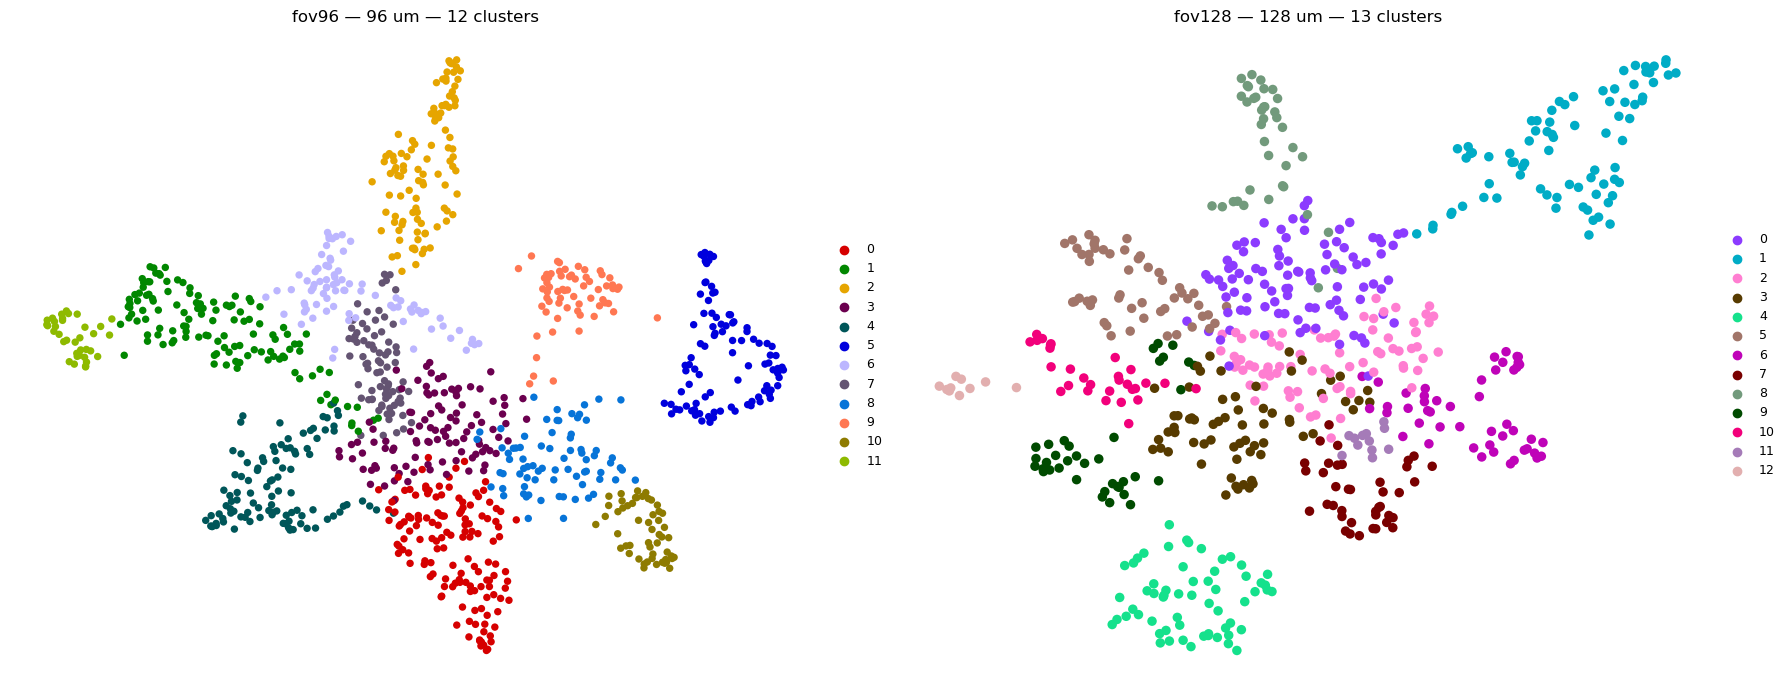

In [5]:
fig, axes = plt.subplots(1, len(CONFIGS), figsize=(9.0 * len(CONFIGS), 7.0))
for ax, k in zip(np.atleast_1d(axes), CONFIGS):
    sc.pl.umap(
        W[k],
        color="leiden",
        ax=ax,
        show=False,
        legend_loc="right margin",
        legend_fontsize=9,
        frameon=False,
        title=f"{k} — {CONFIGS[k]} um — {W[k].obs.leiden.nunique()} clusters",
    )
plt.tight_layout()

### b. UMAP by ROI — the batch check

Same embeddings, coloured by ROI of origin. Heavy separation by ROI is the failure mode.
Some is expected: different patients genuinely have different tissue. Read it against
S2's composition-clustering baseline rather than against perfect mixing.

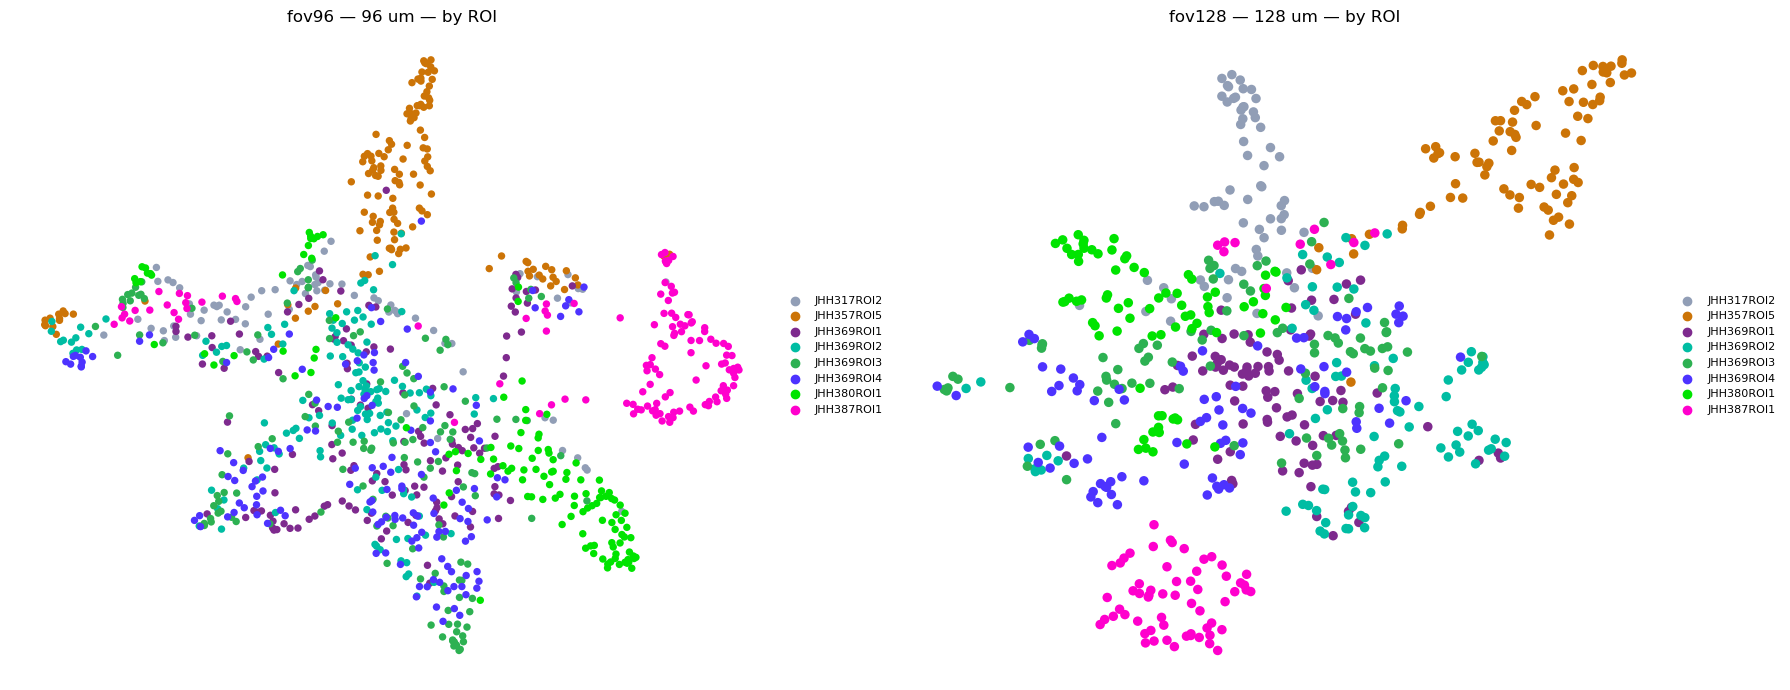

In [6]:
fig, axes = plt.subplots(1, len(CONFIGS), figsize=(9.0 * len(CONFIGS), 7.0))
for ax, k in zip(np.atleast_1d(axes), CONFIGS):
    sc.pl.umap(
        W[k],
        color="roi",
        ax=ax,
        show=False,
        legend_loc="right margin",
        legend_fontsize=8,
        frameon=False,
        title=f"{k} — {CONFIGS[k]} um — by ROI",
    )
plt.tight_layout()

## Tissue maps — one figure per ROI

Three panels each: **96 µm windows, 128 µm windows, then cell types on the far right**,
so the cell-type legend sits in the outer margin and cannot overlap a plot. Cluster
legends sit below their own panel and list only the clusters actually present in that
ROI.

The cell panel uses `sc.pl.embedding(basis='spatial')`; the window panels deliberately
do **not** — scanpy sizes markers in points, so squares only tile if you guess a size
matching the figure geometry, and the gaps that produces are exactly what hides
contiguity. `imc_tm.plot_window_map` draws each window as a real data-coordinate square
instead, so the two scales stay comparable and adjacent windows share an edge. White
gaps are windows the 10-cell filter dropped.

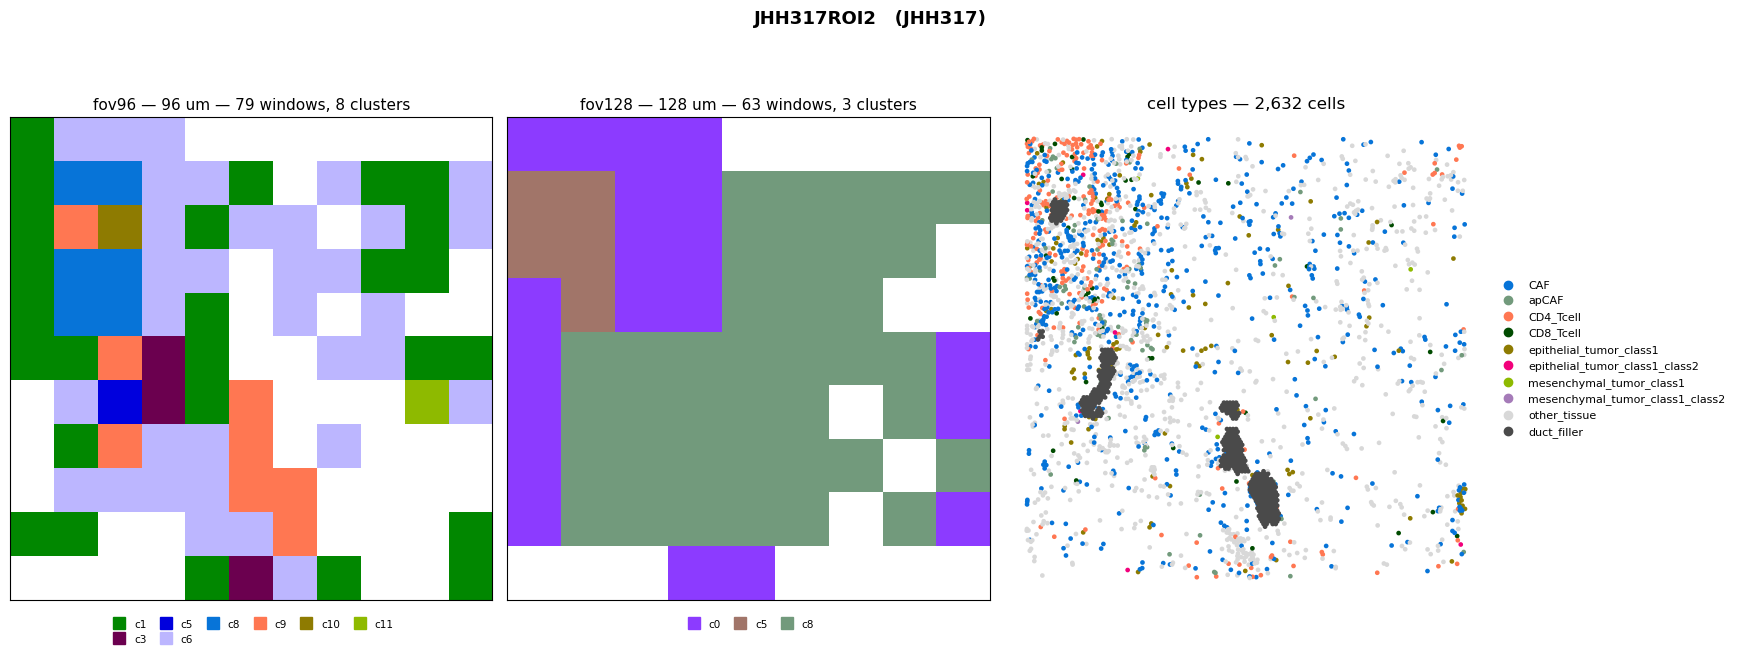

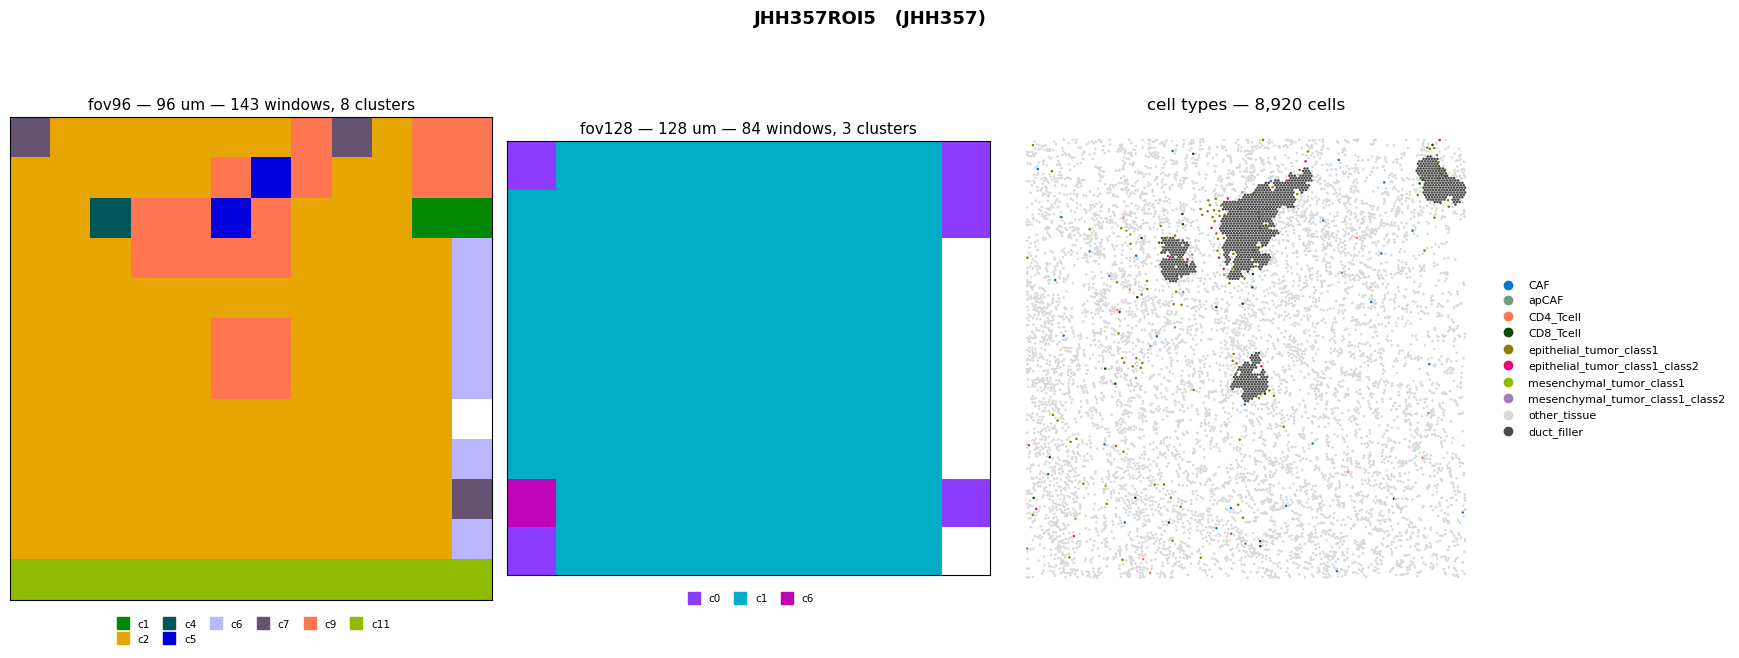

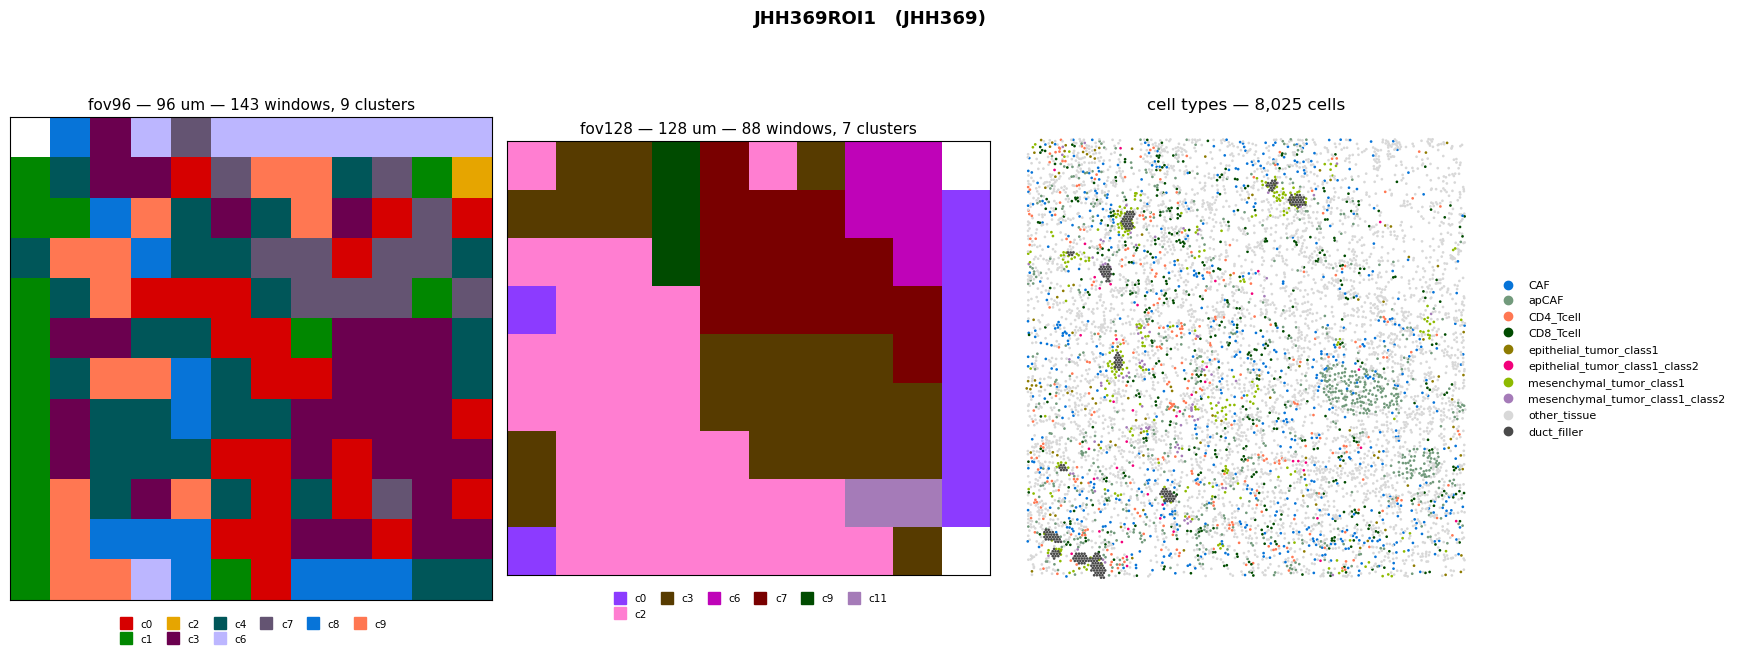

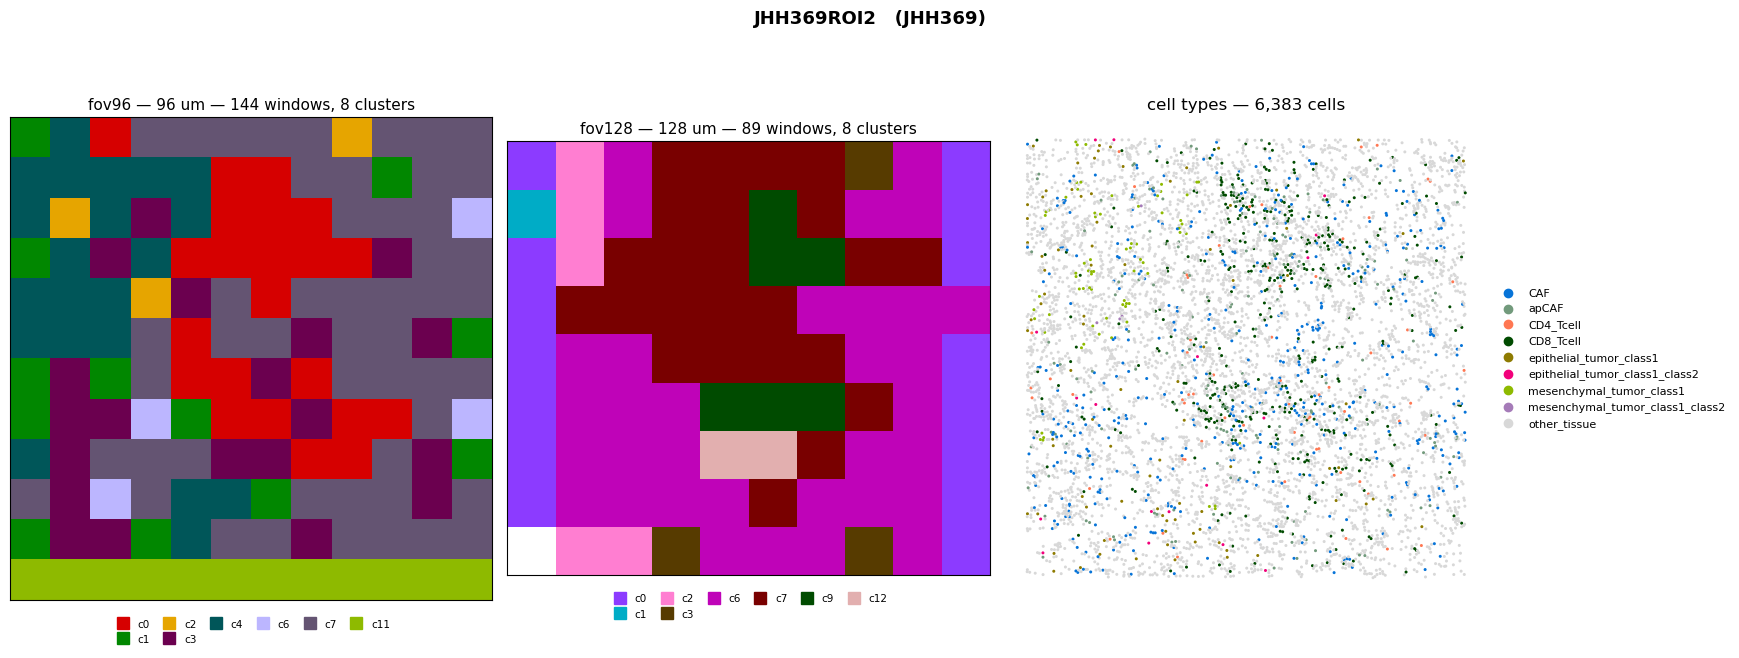

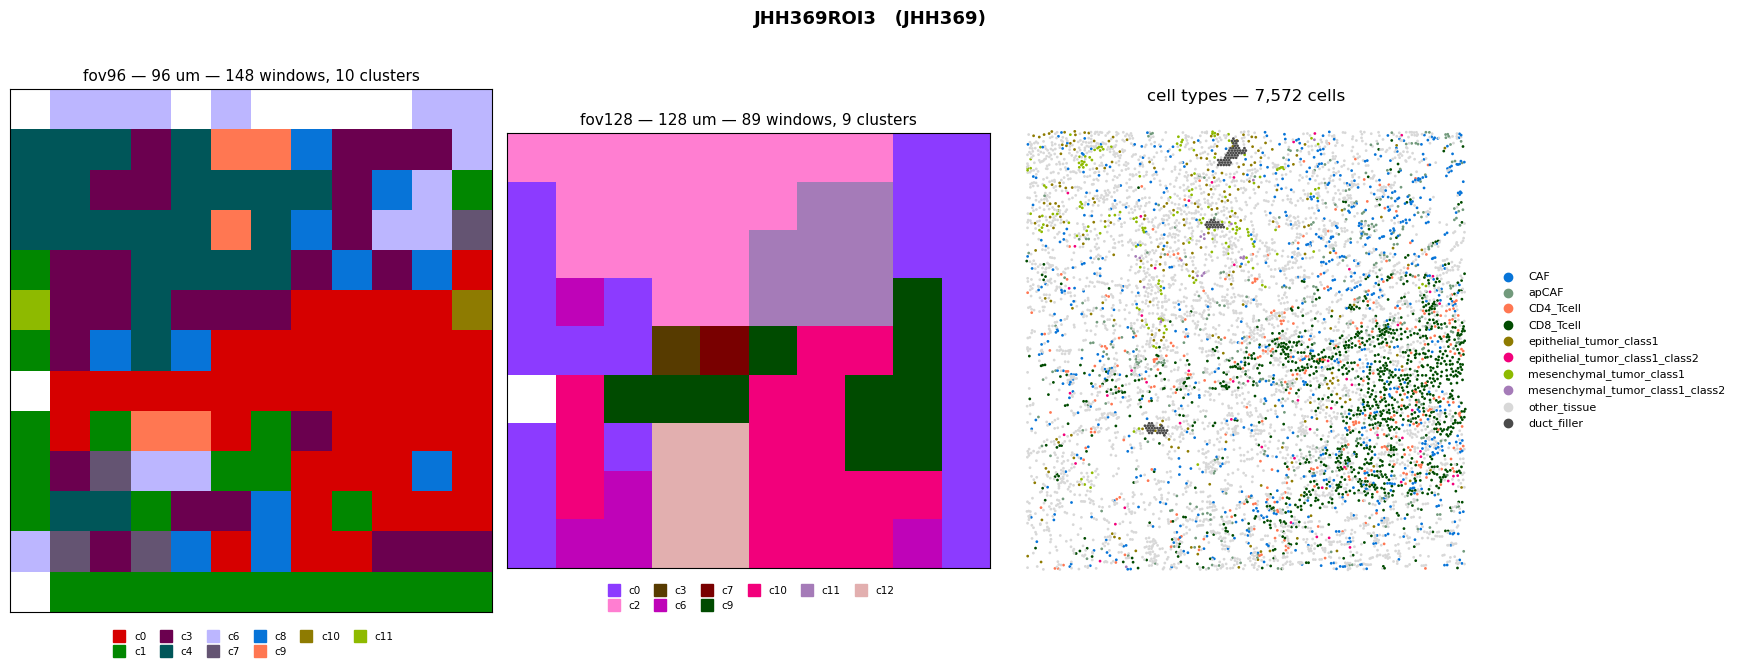

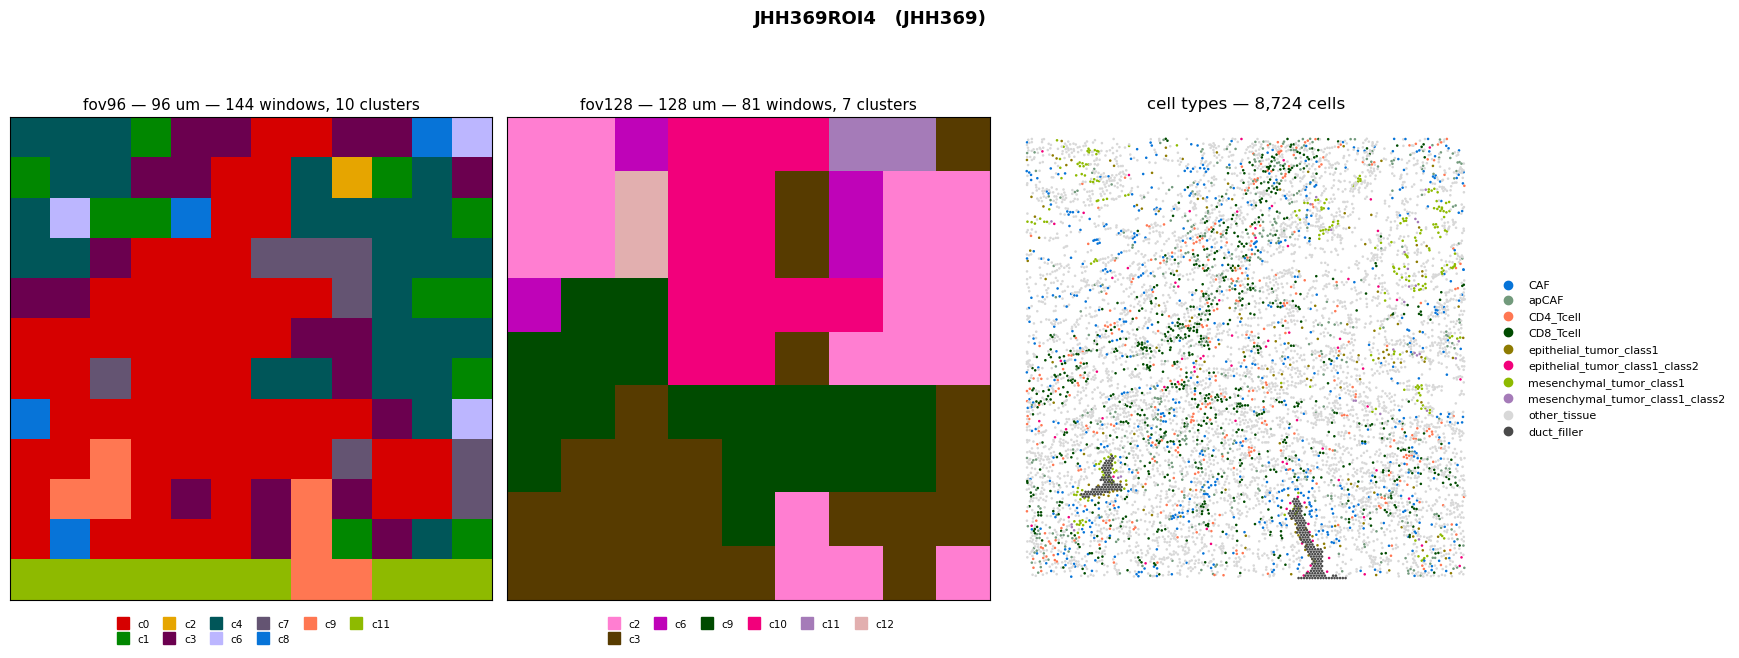

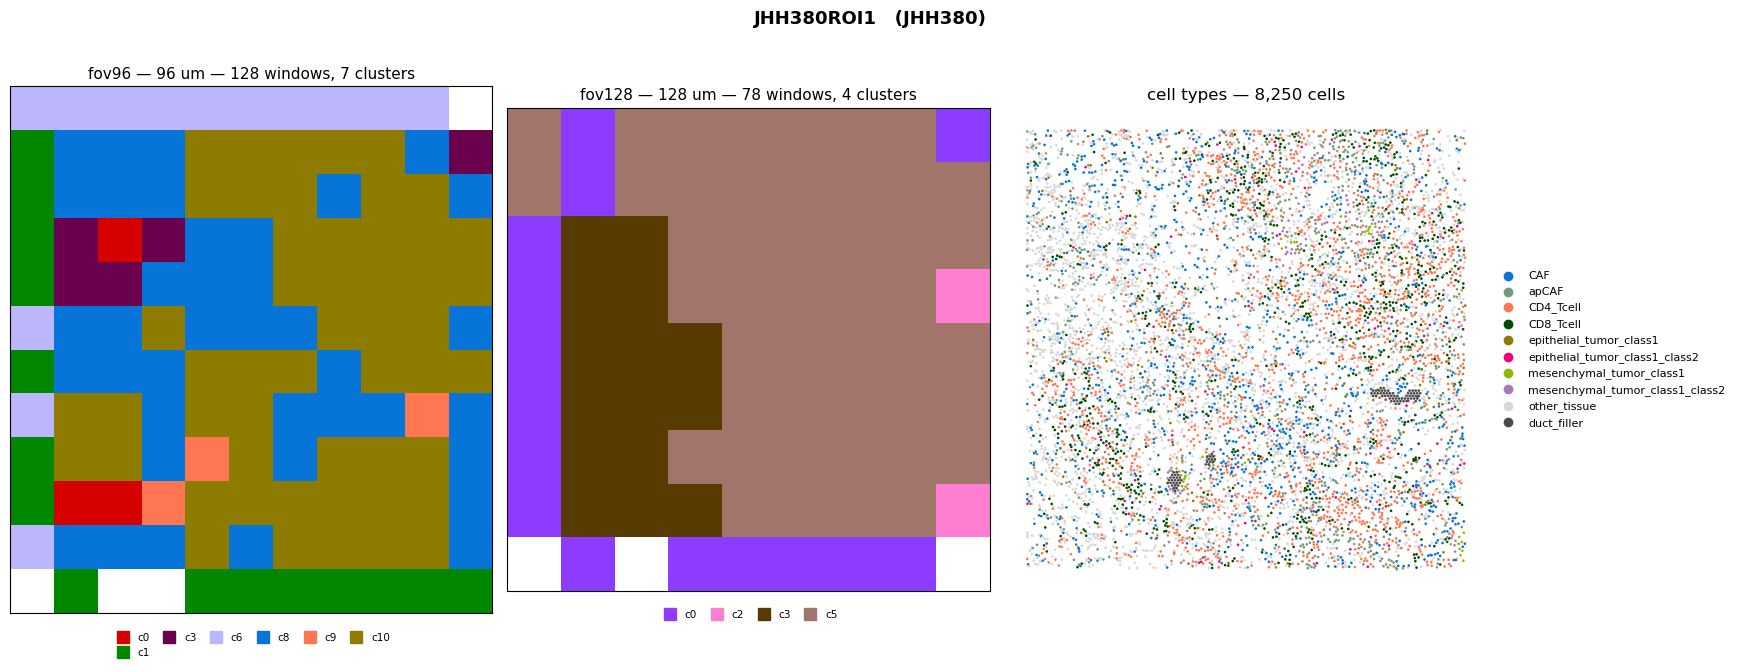

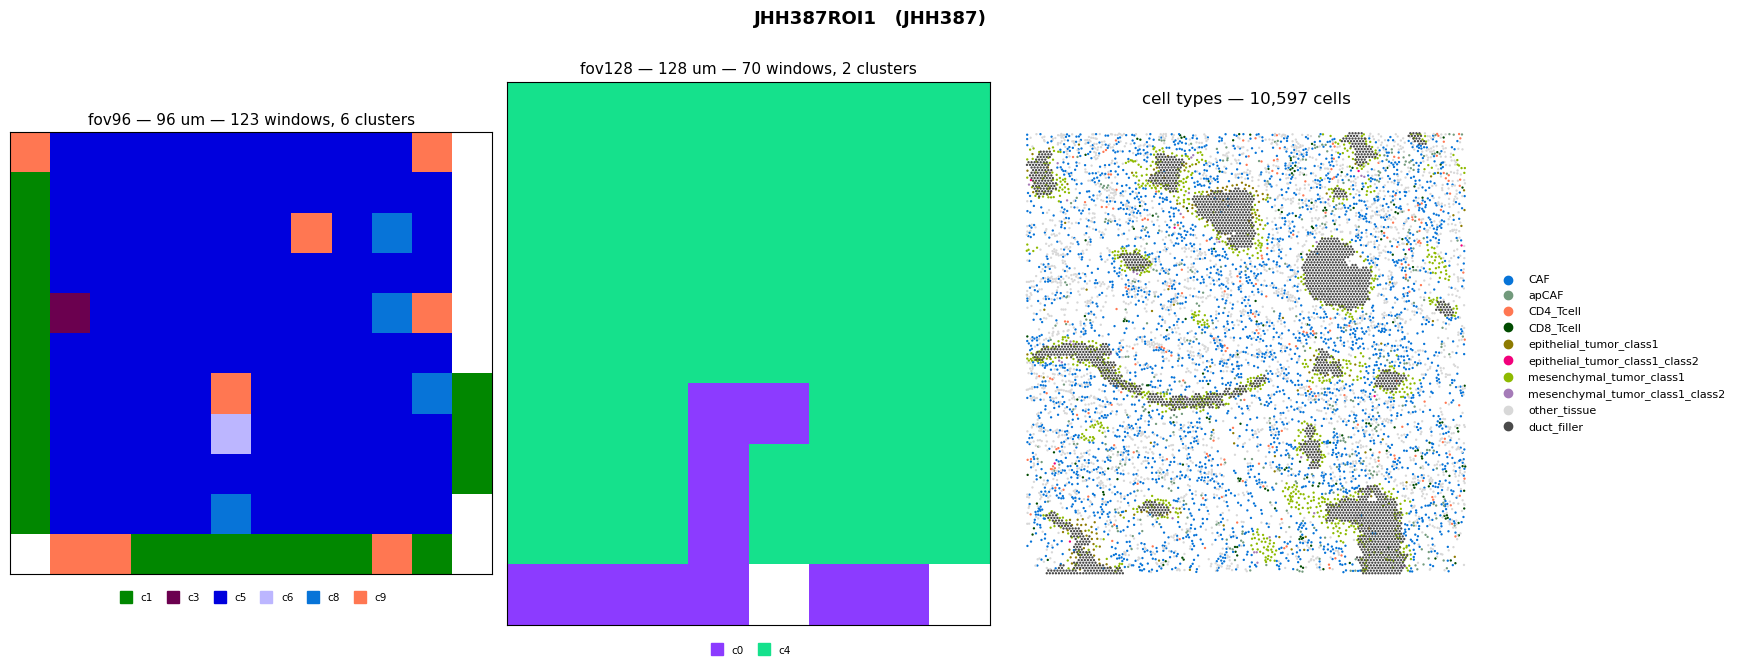

In [7]:
CT_COLORS = {t: to_hex(c) for t, c in imc_tm.palette().items()}

for r in ROIS:
    cs = cells[cells.obs.roi == r].copy()
    fig, axes = plt.subplots(1, 3, figsize=(17.5, 6.4))

    # --- the two window panels, cluster legend beneath each -------------------
    for j, k in enumerate(CONFIGS):
        w = W[k][W[k].obs.roi == r]
        pal = dict(zip(W[k].obs.leiden.cat.categories, W[k].uns["leiden_colors"]))
        present = [
            c for c in W[k].obs.leiden.cat.categories if (w.obs.leiden == c).any()
        ]
        imc_tm.plot_window_map(
            axes[j],
            w.obsm["spatial"],
            [pal[c] for c in w.obs.leiden],
            float(w.obs.fov_um.iloc[0]),
        )
        axes[j].set_xticks([])
        axes[j].set_yticks([])
        axes[j].set_title(
            f"{k} — {CONFIGS[k]} um — {w.n_obs} windows, {len(present)} clusters",
            fontsize=11,
        )
        h = [
            plt.Line2D([0], [0], marker="s", ls="", ms=8, color=pal[c], label=f"c{c}")
            for c in present
        ]
        axes[j].legend(
            handles=h,
            loc="upper center",
            bbox_to_anchor=(0.5, -0.02),
            ncol=min(6, len(h)),
            fontsize=7.5,
            frameon=False,
            handletextpad=0.4,
            columnspacing=0.9,
        )

    # --- cell types LAST, so its right-margin legend has clear space ----------
    cs.uns["cell_type_colors"] = [CT_COLORS[t] for t in imc_tm.CELL_TYPES]
    sc.pl.embedding(
        cs,
        basis="spatial",
        color="cell_type",
        ax=axes[2],
        show=False,
        frameon=False,
        legend_loc="right margin",
        legend_fontsize=8,
        title=f"cell types — {cs.n_obs:,} cells",
    )
    axes[2].set_aspect("equal")

    fig.suptitle(
        f"{r}   ({cs.obs.patient.iloc[0]})", y=1.02, fontsize=13, weight="bold"
    )
    plt.tight_layout()
    plt.show()

## What each cluster is made of

### a. Heatmaps of mean cell-type fraction

Two views of the same clusters, drawn with `seaborn.heatmap` so every cell carries its
value:

- **left — classified biology only**, renormalised so each cluster's eight values sum to
  1. This is the readable view: `other_tissue` is ~68% of a typical window and would
  otherwise set the whole colour scale.
- **right — all ten channels**, background included, each cluster summing to 1. This is
  what the windows actually contain, and it shows how much of any cluster is background
  rather than measured biology.

The two are on **separate colour scales** by necessity — the left tops out near 0.7, the
right is dominated by `other_tissue` — so compare within a panel, not across.

=== fov96 (96 um) ===
  66/1052 windows (6.3%) have zero classified biology and are excluded
  per-cluster fractions sum to [1.0000, 1.0000] -- these ARE row-normalised


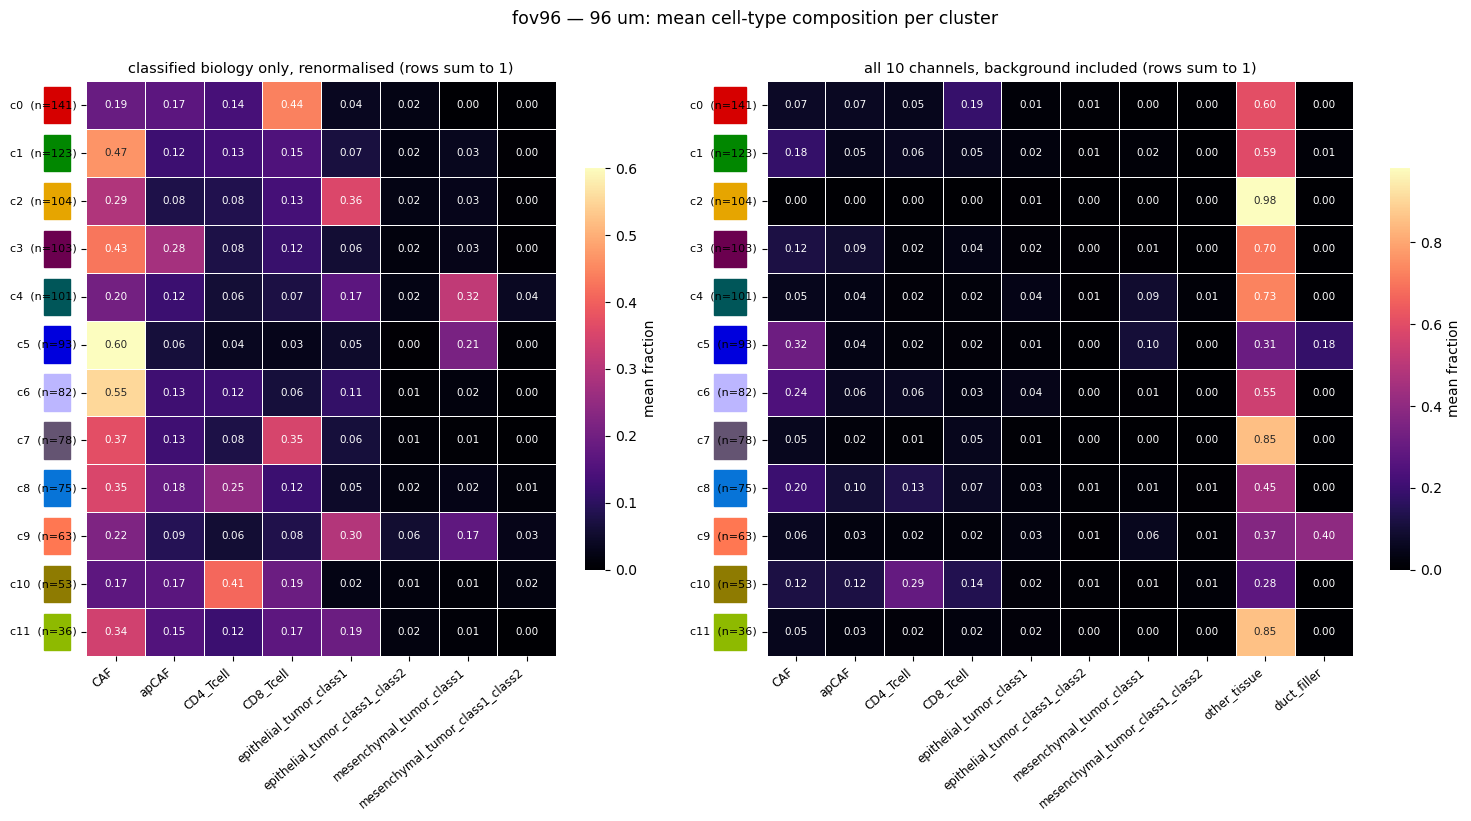

=== fov128 (128 um) ===
  24/642 windows (3.7%) have zero classified biology and are excluded
  per-cluster fractions sum to [1.0000, 1.0000] -- these ARE row-normalised


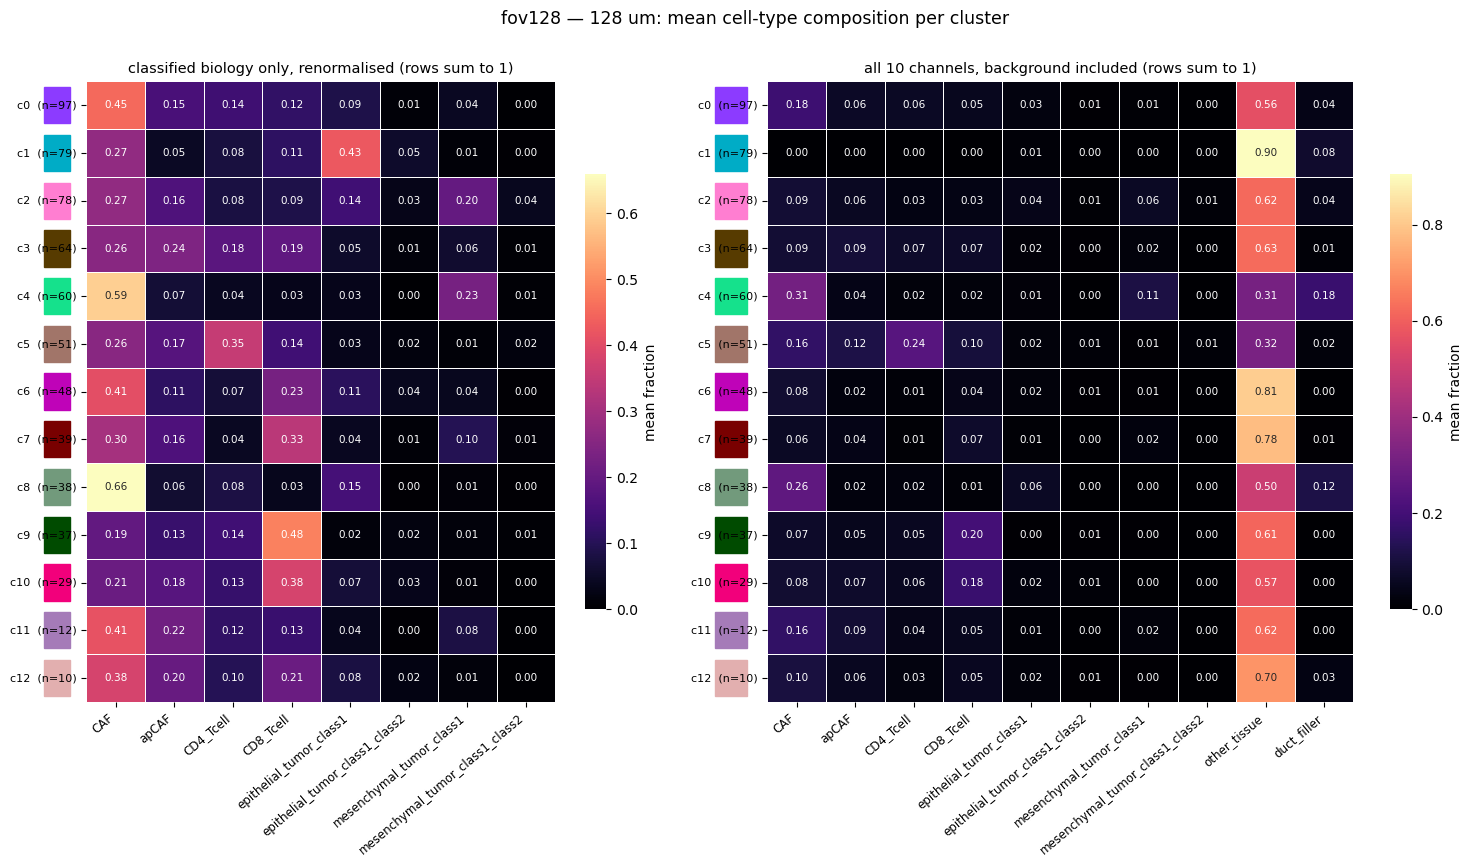

In [8]:
def biology_fractions(w):
    """Biology composition renormalised per window, with all-background windows as NaN.

    patch_ncv sums to 1 over all TEN channels, but background is ~68% of a typical
    window, so the biology block sums to only ~0.32 and has to be renormalised to be
    readable. The trap: some windows contain ZERO classified biology (5.9% at 96 um,
    3.2% at 128 um), and dividing those by a clipped zero turns them into all-zero rows
    that silently drag every cluster mean below 1 -- per-cluster sums ran 0.42 to 1.00.
    Marking them NaN instead makes the mean skip them, and cluster sums land at exactly
    1.0000.
    """
    idx = [imc_tm.CELL_TYPES.index(t) for t in imc_tm.BIOLOGY_TYPES]
    b = np.asarray(w.obsm["composition"])[:, idx]
    tot = b.sum(axis=1, keepdims=True)
    return np.where(tot > 0, b / np.where(tot > 0, tot, 1.0), np.nan), (tot[:, 0] <= 0)


def comp_view(w):
    """scanpy-native view whose X is the renormalised biology composition."""
    b, empty = biology_fractions(w)
    v = ad.AnnData(X=np.nan_to_num(b, nan=0.0).astype(np.float32), obs=w.obs.copy())
    v.var_names = list(imc_tm.BIOLOGY_TYPES)
    v.uns["leiden_colors"] = w.uns["leiden_colors"]
    v.obs["has_biology"] = ~empty
    return v[v.obs.has_biology].copy()  # drop all-background windows from the mean


views = {k: comp_view(W[k]) for k in CONFIGS}
for k in CONFIGS:
    _, empty = biology_fractions(W[k])
    chk = pd.DataFrame(views[k].X, columns=imc_tm.BIOLOGY_TYPES)
    chk["leiden"] = np.asarray(views[k].obs.leiden)
    sums = chk.groupby("leiden", observed=True)[imc_tm.BIOLOGY_TYPES].mean().sum(axis=1)
    print(f"=== {k} ({CONFIGS[k]} um) ===")
    print(
        f"  {int(empty.sum())}/{len(empty)} windows ({100 * empty.mean():.1f}%) have zero "
        f"classified biology and are excluded"
    )
    print(
        f"  per-cluster fractions sum to [{sums.min():.4f}, {sums.max():.4f}] "
        f"-- these ARE row-normalised"
    )

    # --- assemble both matrices -------------------------------------------------
    bio = pd.DataFrame(views[k].X, columns=imc_tm.BIOLOGY_TYPES)
    bio["leiden"] = np.asarray(views[k].obs.leiden)
    bio = bio.groupby("leiden", observed=True)[imc_tm.BIOLOGY_TYPES].mean()

    allc = pd.DataFrame(W[k].obsm["composition"], columns=imc_tm.CELL_TYPES)
    allc["leiden"] = np.asarray(W[k].obs.leiden)
    n_win = allc.groupby("leiden", observed=True).size()
    allc = allc.groupby("leiden", observed=True)[imc_tm.CELL_TYPES].mean()

    order = [c for c in W[k].obs.leiden.cat.categories if c in bio.index]
    bio, allc = bio.loc[order], allc.loc[order]
    ylabels = [f"c{c}  (n={n_win[c]})" for c in order]
    cpal = dict(zip(W[k].obs.leiden.cat.categories, W[k].uns["leiden_colors"]))

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(9.0 + 0.62 * len(imc_tm.CELL_TYPES), 0.46 * len(order) + 2.6),
        gridspec_kw={
            "width_ratios": [len(imc_tm.BIOLOGY_TYPES), len(imc_tm.CELL_TYPES)]
        },
    )
    for ax, mat, title in [
        (axes[0], bio, "classified biology only, renormalised (rows sum to 1)"),
        (axes[1], allc, "all 10 channels, background included (rows sum to 1)"),
    ]:
        sns.heatmap(
            mat,
            ax=ax,
            cmap="magma",
            annot=True,
            fmt=".2f",
            annot_kws={"fontsize": 7.5},
            linewidths=0.4,
            linecolor="white",
            cbar_kws={"label": "mean fraction", "shrink": 0.7},
        )
        ax.set_title(title, fontsize=10.5)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=8.5)
        ax.set_yticklabels(ylabels, rotation=0, fontsize=8)
        for yi, c in enumerate(order):  # cluster colour chip outside the axes
            ax.add_patch(
                plt.Rectangle(
                    (-0.09, yi + 0.12),
                    0.055,
                    0.76,
                    color=cpal[c],
                    transform=ax.get_yaxis_transform(),
                    clip_on=False,
                )
            )
    fig.suptitle(
        f"{k} — {CONFIGS[k]} um: mean cell-type composition per cluster",
        y=1.005,
        fontsize=12.5,
    )
    plt.tight_layout()
    plt.show()

## Spread of composition across ROIs

Four grids per config, eight in total. All of them use the **all-ten-channel** fractions
(`patch_ncv`, which sums to 1 per window), and all are boxes over ROIs with one dot per
ROI.

**Absent clusters count as zero.** `groupby` emits no row for a (cluster, ROI) pair
that does not occur, so the table is reindexed to the full product and filled with 0 —
every box spans all 8 ROIs. A cluster confined to a couple of sections therefore reads
as a **low box with a few high dots**, rather than as a deceptively tight box over the
handful of ROIs it happens to occupy. The `R/8` on each label is the number of ROIs it
actually occurs in, and ≤2 is flagged in red.

| | panels | x-axis | y-axis |
|---|---|---|---|
| **b1** | cell type | cluster | fixed 0–1 |
| **b2** | cell type | cluster | 0 to that cell type's max across BOTH configs |
| **c1** | cluster | all 10 types | fixed 0–1 |
| **c2** | cluster | 8 biology types only | 0 to the max biology value across BOTH configs |

The fixed 0–1 versions are comparable to everything else in the notebook; the rescaled
versions make the low-abundance types readable, which a 0–1 axis flattens to nothing.
**c2 drops the two background types from the x-axis but not from the arithmetic** — the
values are still fractions of all cells, so they do not sum to 1 across the eight boxes.

In [9]:
PAD = 1.08  # headroom above the largest observed value

PER = {}  # per (cluster, roi) mean composition, per config
for k in CONFIGS:
    w = W[k]
    df = pd.DataFrame(np.asarray(w.obsm["composition"]), columns=imc_tm.CELL_TYPES)
    df["leiden"] = np.asarray(w.obs.leiden).astype(str)
    df["roi"] = np.asarray(w.obs.roi).astype(str)
    g = df.groupby(["leiden", "roi"], observed=True)[imc_tm.CELL_TYPES].mean()
    # A cluster absent from an ROI produces NO ROW from groupby. Treat that as a
    # ZERO contribution rather than a missing observation, so every box spans all
    # ROIs and a rare cluster reads as a low box rather than a deceptively tight one.
    full = pd.MultiIndex.from_product(
        [[str(c) for c in w.obs.leiden.cat.categories], list(ROIS)],
        names=["leiden", "roi"],
    )
    PER[k] = g.reindex(full, fill_value=0.0).reset_index()

# HOW MANY ROIs each cluster actually occurs in. groupby(observed=True) emits no row for
# a (cluster, ROI) pair that does not occur -- the value is ABSENT, not 0 and not NaN --
# so a box spans only the ROIs where that cluster exists. Without this on the figure a
# tight box over 2 ROIs looks exactly like a tight box over 8, which inverts the whole
# point of the panel. Every fov128 cluster is missing from at least one ROI.
# Count ROIs where the cluster OCCURS, i.e. rows that are not all-zero after the
# zero-fill. Summing over ROIs first collapses that to one row per cluster and always
# yields 1 -- which is what the previous version did.
N_ROI = {}
for k in CONFIGS:
    occ = PER[k].set_index(["leiden", "roi"])[imc_tm.CELL_TYPES].sum(axis=1) > 0
    N_ROI[k] = occ.groupby(level="leiden").sum().astype(int).to_dict()
print("ROIs each cluster occurs in:")
for k in CONFIGS:
    print(
        f"   {k:<7s} "
        + "  ".join(f"c{c}:{N_ROI[k][c]}" for c in sorted(N_ROI[k], key=int))
    )

# shared scales, computed ACROSS both configs so the two are directly comparable
YMAX_TYPE = {t: PAD * max(PER[k][t].max() for k in CONFIGS) for t in imc_tm.CELL_TYPES}
YMAX_BIO = PAD * max(PER[k][imc_tm.BIOLOGY_TYPES].max().max() for k in CONFIGS)
print("per-cell-type y-max (both configs):")
for t in imc_tm.CELL_TYPES:
    print(f"   {t:34s} {YMAX_TYPE[t]:.3f}")
print(f"shared biology y-max for c2: {YMAX_BIO:.3f}")


def _panels(n):
    nc = int(np.ceil(np.sqrt(n)))
    return nc, int(np.ceil(n / nc))


def grid_by_type(k, ylim):
    # panels = cell type, x = cluster. ylim: a scalar, or a {type: max} mapping.
    w, per = W[k], PER[k]
    cl_ids = [str(c) for c in w.obs.leiden.cat.categories]
    cpal = {
        str(c): v for c, v in zip(w.obs.leiden.cat.categories, w.uns["leiden_colors"])
    }
    NC, NR = _panels(len(imc_tm.CELL_TYPES))
    side = max(13.0, 0.26 * len(cl_ids) * NC)
    fig, axes = plt.subplots(NR, NC, sharex=True, figsize=(side, side))
    axes = np.atleast_1d(axes).ravel()
    for ax, t in zip(axes, imc_tm.CELL_TYPES):
        vals = [per.loc[per.leiden == c, t].values for c in cl_ids]
        bp = ax.boxplot(
            vals,
            positions=range(len(cl_ids)),
            widths=0.6,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color="black", lw=1.1),
        )
        for patch, c in zip(bp["boxes"], cl_ids):
            patch.set_facecolor(cpal[c])
            patch.set_alpha(0.78)
            patch.set_edgecolor("0.3")
        for xi, v in enumerate(vals):
            if len(v):
                ax.scatter(
                    np.full(len(v), xi) + np.linspace(-0.15, 0.15, len(v)),
                    v,
                    s=7,
                    color="0.15",
                    zorder=3,
                    linewidths=0,
                )
        ax.set_ylim(0.0, ylim if np.isscalar(ylim) else ylim[t])
        ax.set_title(t, fontsize=9)
        ax.grid(axis="y", alpha=0.25)
        ax.set_xticks(range(len(cl_ids)))
        ax.set_xticklabels(
            [f"c{c}\n{N_ROI[k].get(c, 0)}/{len(ROIS)}" for c in cl_ids], fontsize=6.5
        )
        ax.tick_params(labelbottom=True)
    for ax in axes[len(imc_tm.CELL_TYPES) :]:
        ax.axis("off")
    return fig


def grid_by_cluster(k, types, ylim):
    # panels = cluster, x = `types`. Values stay fractions of ALL cells.
    w, per = W[k], PER[k]
    cl_ids = [str(c) for c in w.obs.leiden.cat.categories]
    cpal = {
        str(c): v for c, v in zip(w.obs.leiden.cat.categories, w.uns["leiden_colors"])
    }
    tpal = imc_tm.palette()
    NC, NR = _panels(len(cl_ids))
    side = max(13.0, 3.7 * NC)
    fig, axes = plt.subplots(NR, NC, sharex=True, sharey=True, figsize=(side, side))
    axes = np.atleast_1d(axes).ravel()
    for ax, c in zip(axes, cl_ids):
        sub = per[per.leiden == c]
        vals = [sub[t].dropna().values for t in types]
        bp = ax.boxplot(
            vals,
            positions=range(len(types)),
            widths=0.6,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color="black", lw=1.1),
        )
        for patch, t in zip(bp["boxes"], types):
            patch.set_facecolor(tpal[t])
            patch.set_alpha(0.8)
            patch.set_edgecolor("0.3")
        for xi, v in enumerate(vals):
            if len(v):
                ax.scatter(
                    np.full(len(v), xi) + np.linspace(-0.15, 0.15, len(v)),
                    v,
                    s=8,
                    color="0.15",
                    zorder=3,
                    linewidths=0,
                )
        nr = int(N_ROI[k].get(c, 0))
        warn = "  (!)" if nr <= 2 else ""  # 1-2 ROIs: the box is not a spread
        ax.set_title(
            f"c{c}   n={int((w.obs.leiden == c).sum())}   {nr}/{len(ROIS)} ROIs{warn}",
            fontsize=9,
            color=("crimson" if nr <= 2 else "black"),
        )
        for sp_ in ax.spines.values():
            sp_.set_color(cpal[c])
            sp_.set_linewidth(2.6)
        ax.set_xlim(-0.6, len(types) - 0.4)
        ax.set_ylim(0.0, ylim)
        ax.grid(axis="y", alpha=0.25)
    for ax in axes[len(cl_ids) :]:
        ax.axis("off")
    bottom_of_col = {}
    for i in range(len(cl_ids)):
        bottom_of_col[i % NC] = i
    for i, ax in enumerate(axes[: len(cl_ids)]):
        ax.set_xticks(range(len(types)))
        if i in bottom_of_col.values():
            ax.set_xticklabels(types, rotation=90, fontsize=7)
            ax.tick_params(labelbottom=True)
        else:
            ax.set_xticklabels([])
            ax.tick_params(labelbottom=False)
    return fig

ROIs each cluster occurs in:
   fov96   c0:5  c1:8  c2:4  c3:7  c4:5  c5:3  c6:8  c7:5  c8:6  c9:7  c10:3  c11:5
   fov128  c0:7  c1:2  c2:5  c3:5  c4:1  c5:2  c6:5  c7:3  c8:1  c9:4  c10:2  c11:3  c12:3
per-cell-type y-max (both configs):
   CAF                                0.450
   apCAF                              0.175
   CD4_Tcell                          0.370
   CD8_Tcell                          0.380
   epithelial_tumor_class1            0.103
   epithelial_tumor_class1_class2     0.026
   mesenchymal_tumor_class1           0.147
   mesenchymal_tumor_class1_class2    0.084
   other_tissue                       1.080
   duct_filler                        0.947
shared biology y-max for c2: 0.450


### b1. Cell type per panel, y fixed 0–1

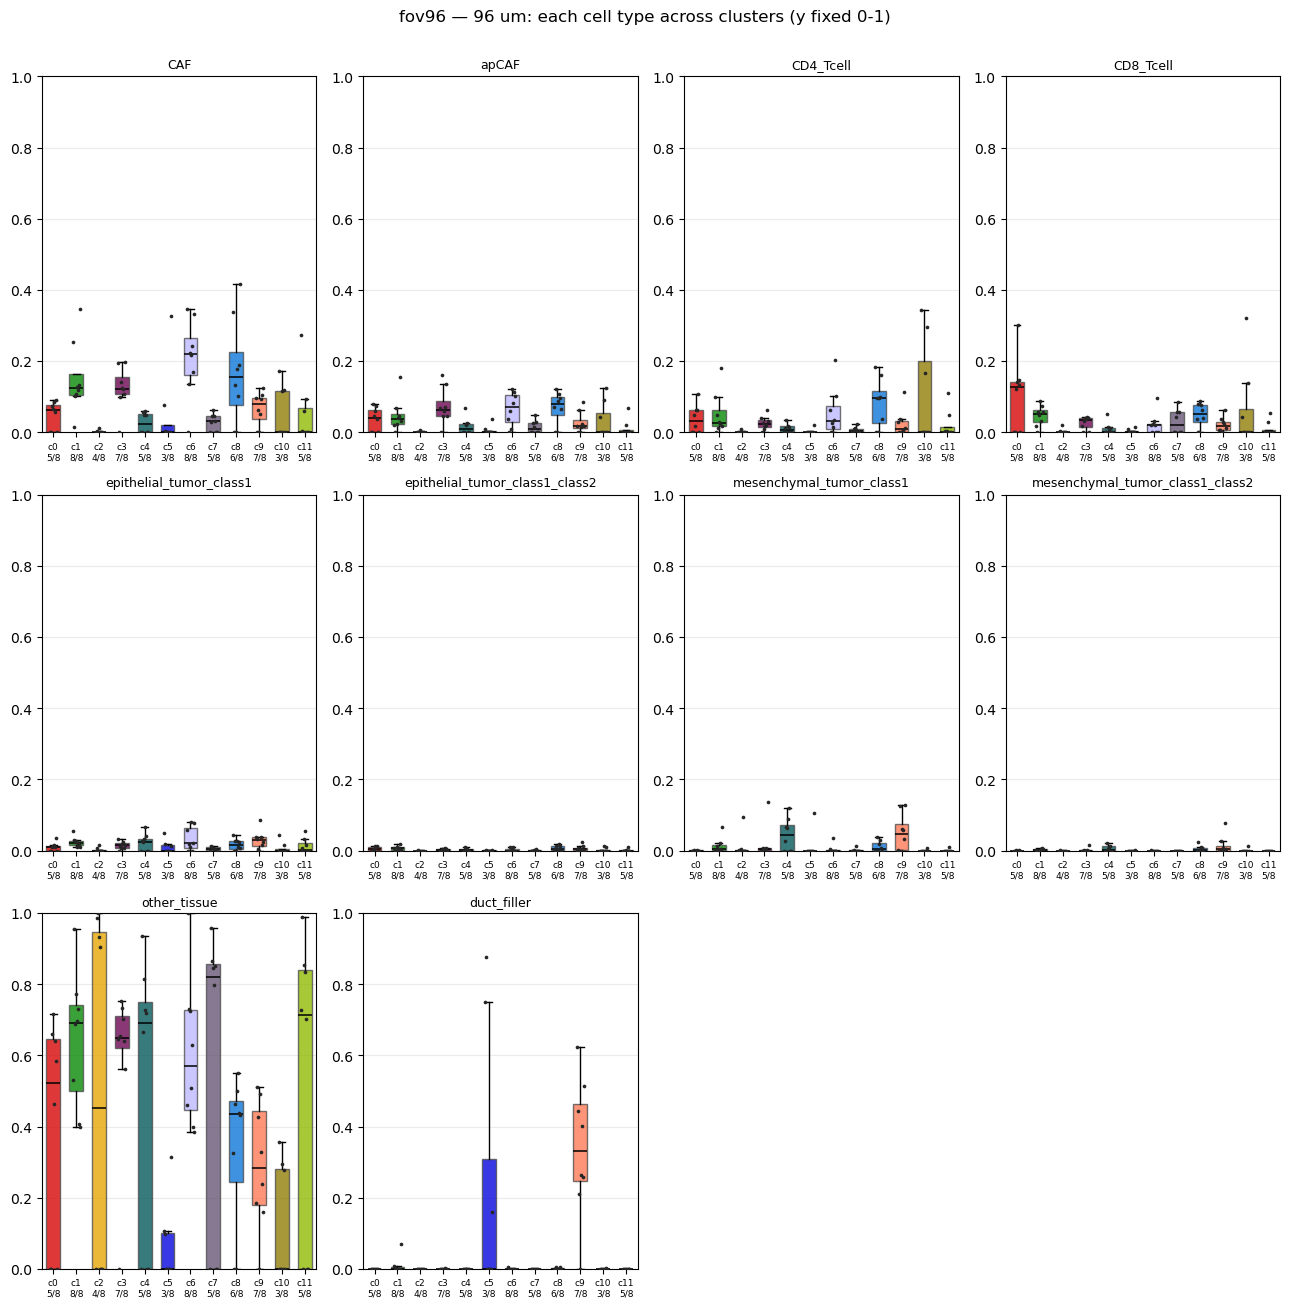

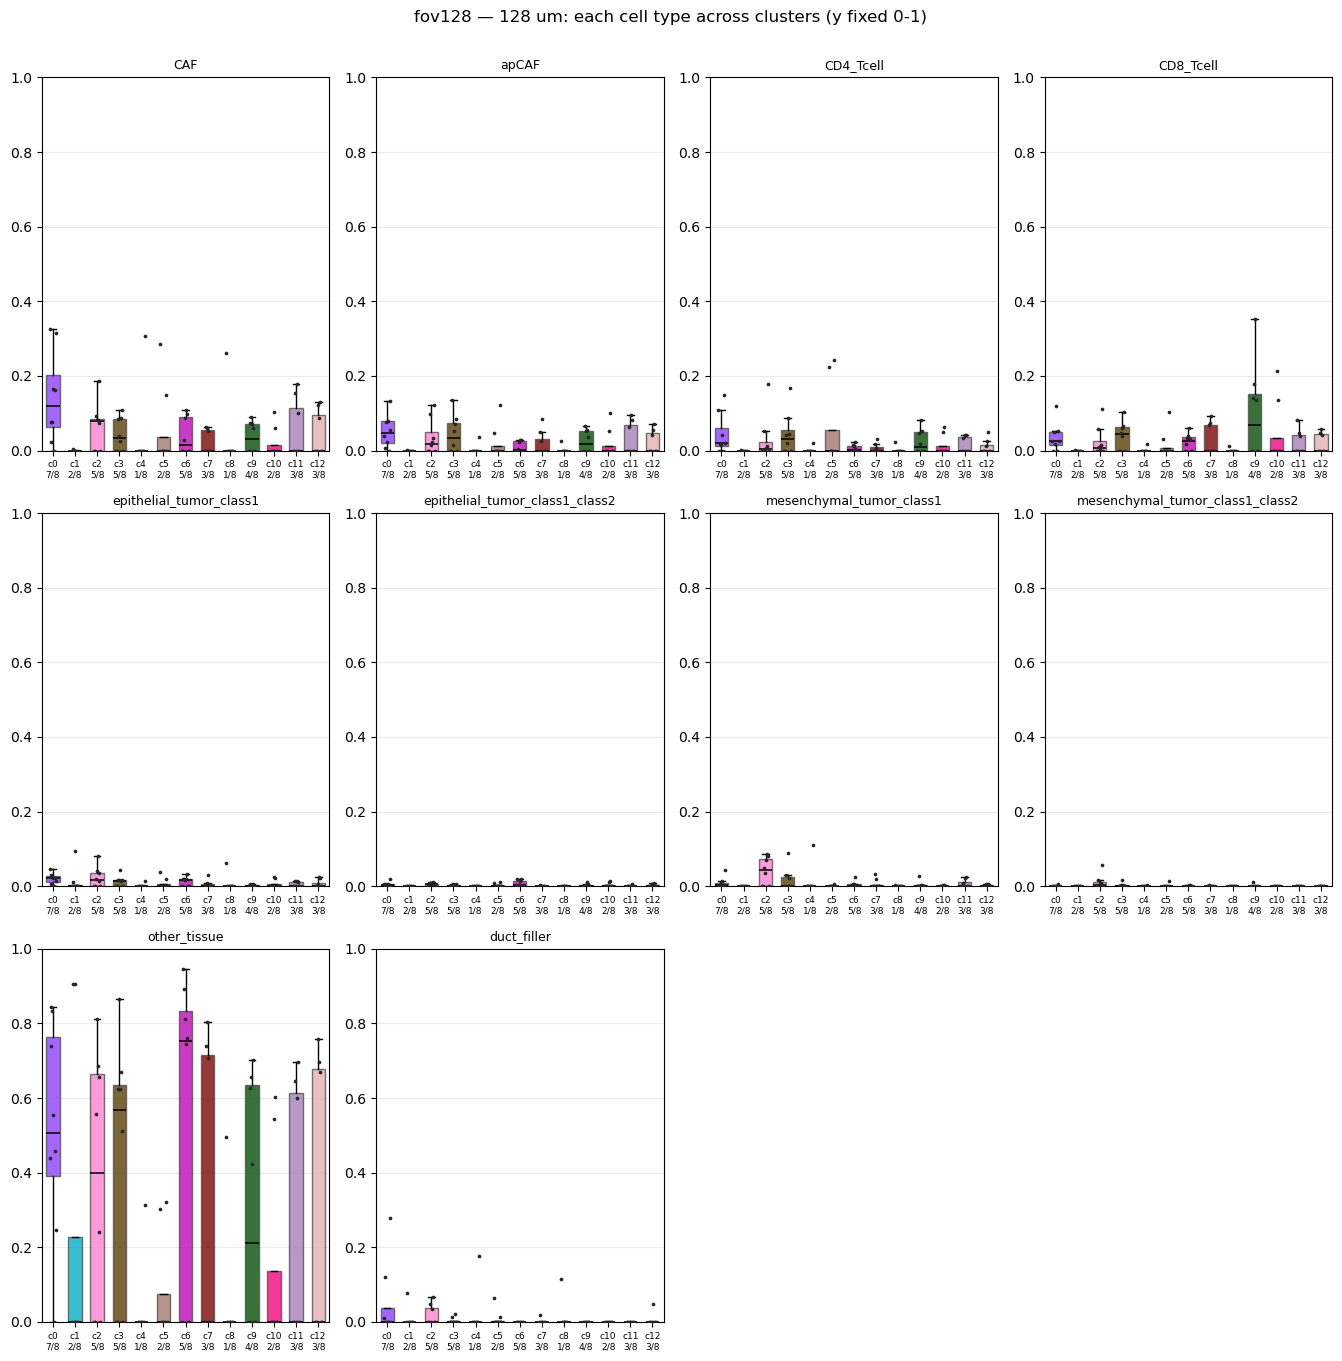

In [10]:
for k in CONFIGS:
    fig = grid_by_type(k, 1.0)
    fig.suptitle(
        f"{k} — {CONFIGS[k]} um: each cell type across clusters (y fixed 0-1)",
        y=1.003,
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()

### b2. Cell type per panel, y rescaled per cell type

Each panel runs 0 to that cell type's largest value across **both** configs, so the two
figures stay comparable to each other while low-abundance types become readable.

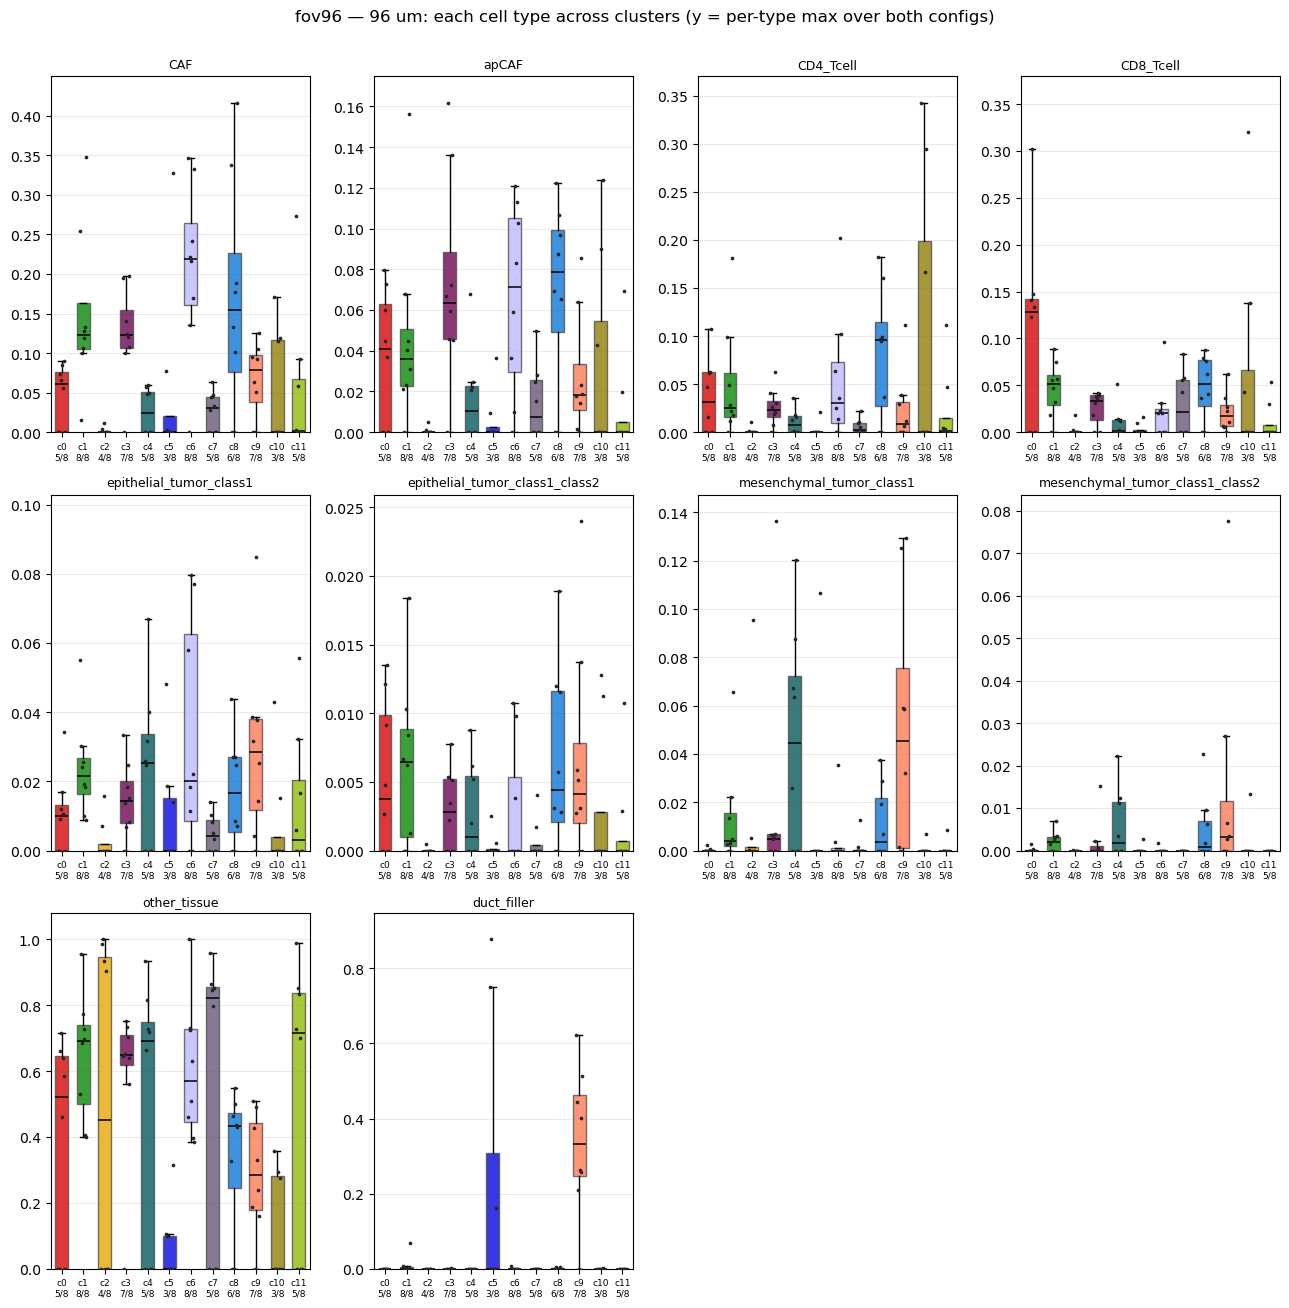

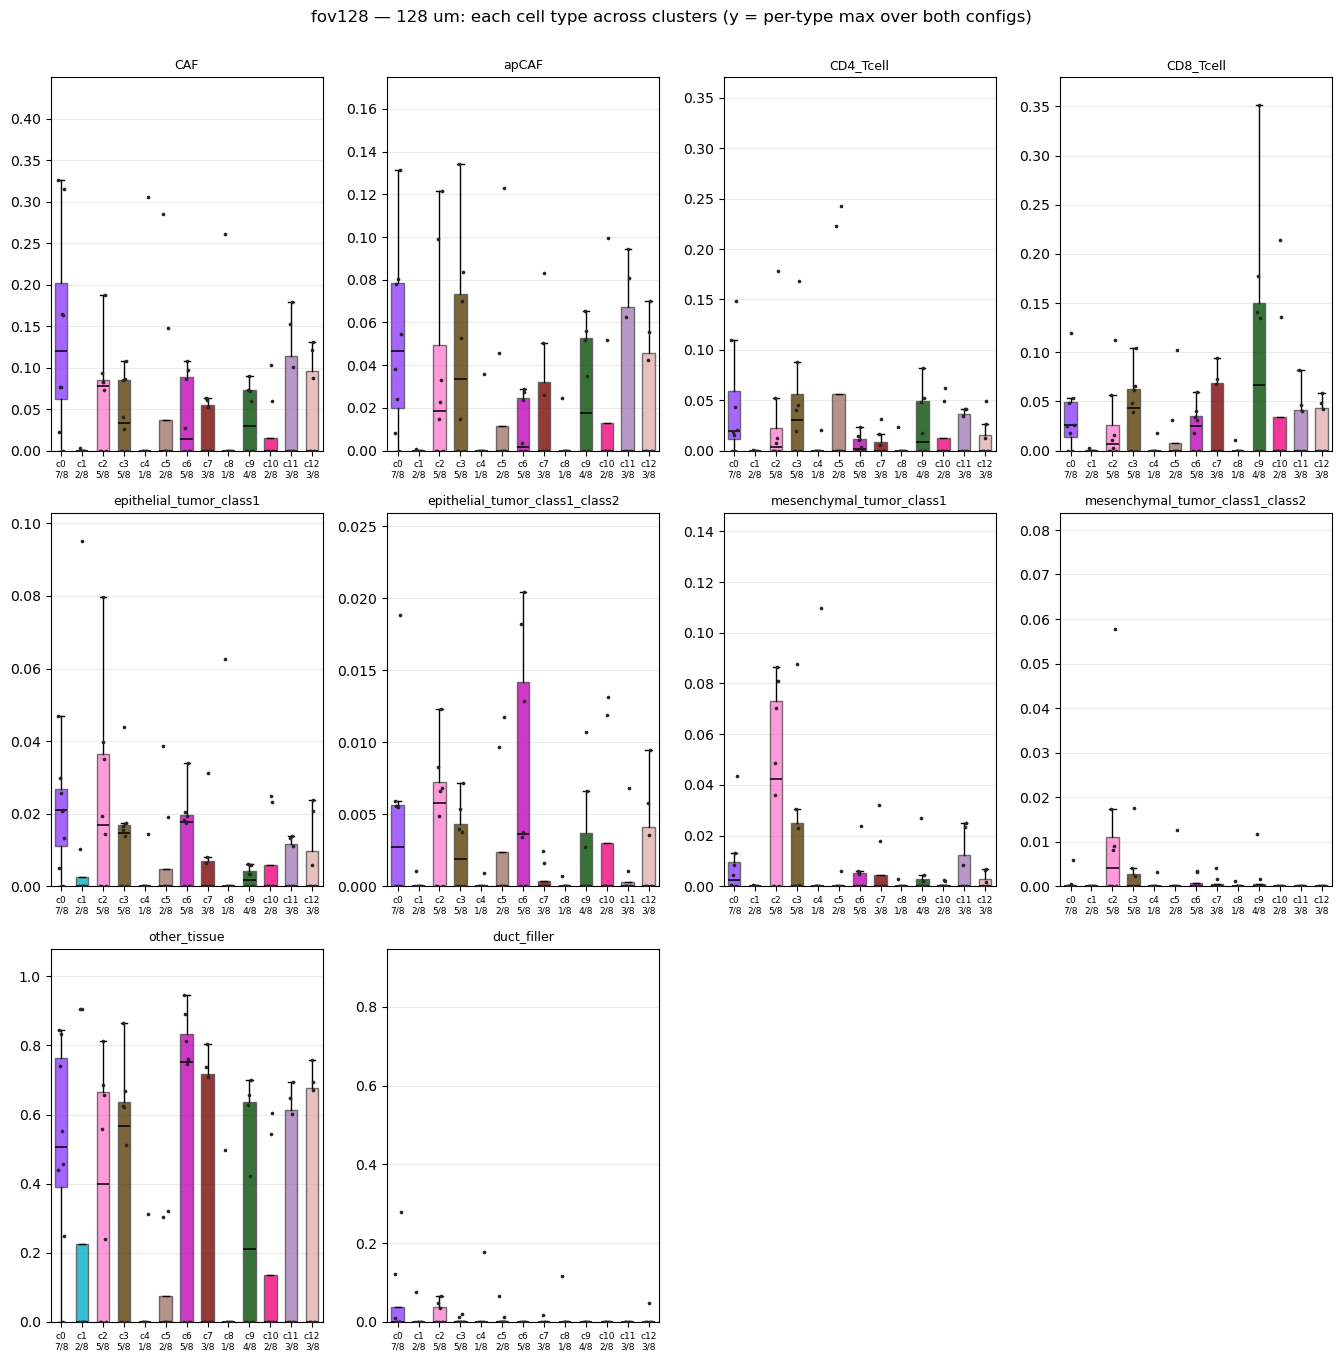

In [11]:
for k in CONFIGS:
    fig = grid_by_type(k, YMAX_TYPE)
    fig.suptitle(
        f"{k} — {CONFIGS[k]} um: each cell type across clusters "
        f"(y = per-type max over both configs)",
        y=1.003,
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()

### c1. Cluster per panel, all ten types, y fixed 0–1

The two greys are usually the tallest boxes; that is the honest picture, since most
windows are mostly background. Values in a panel sum to 1.

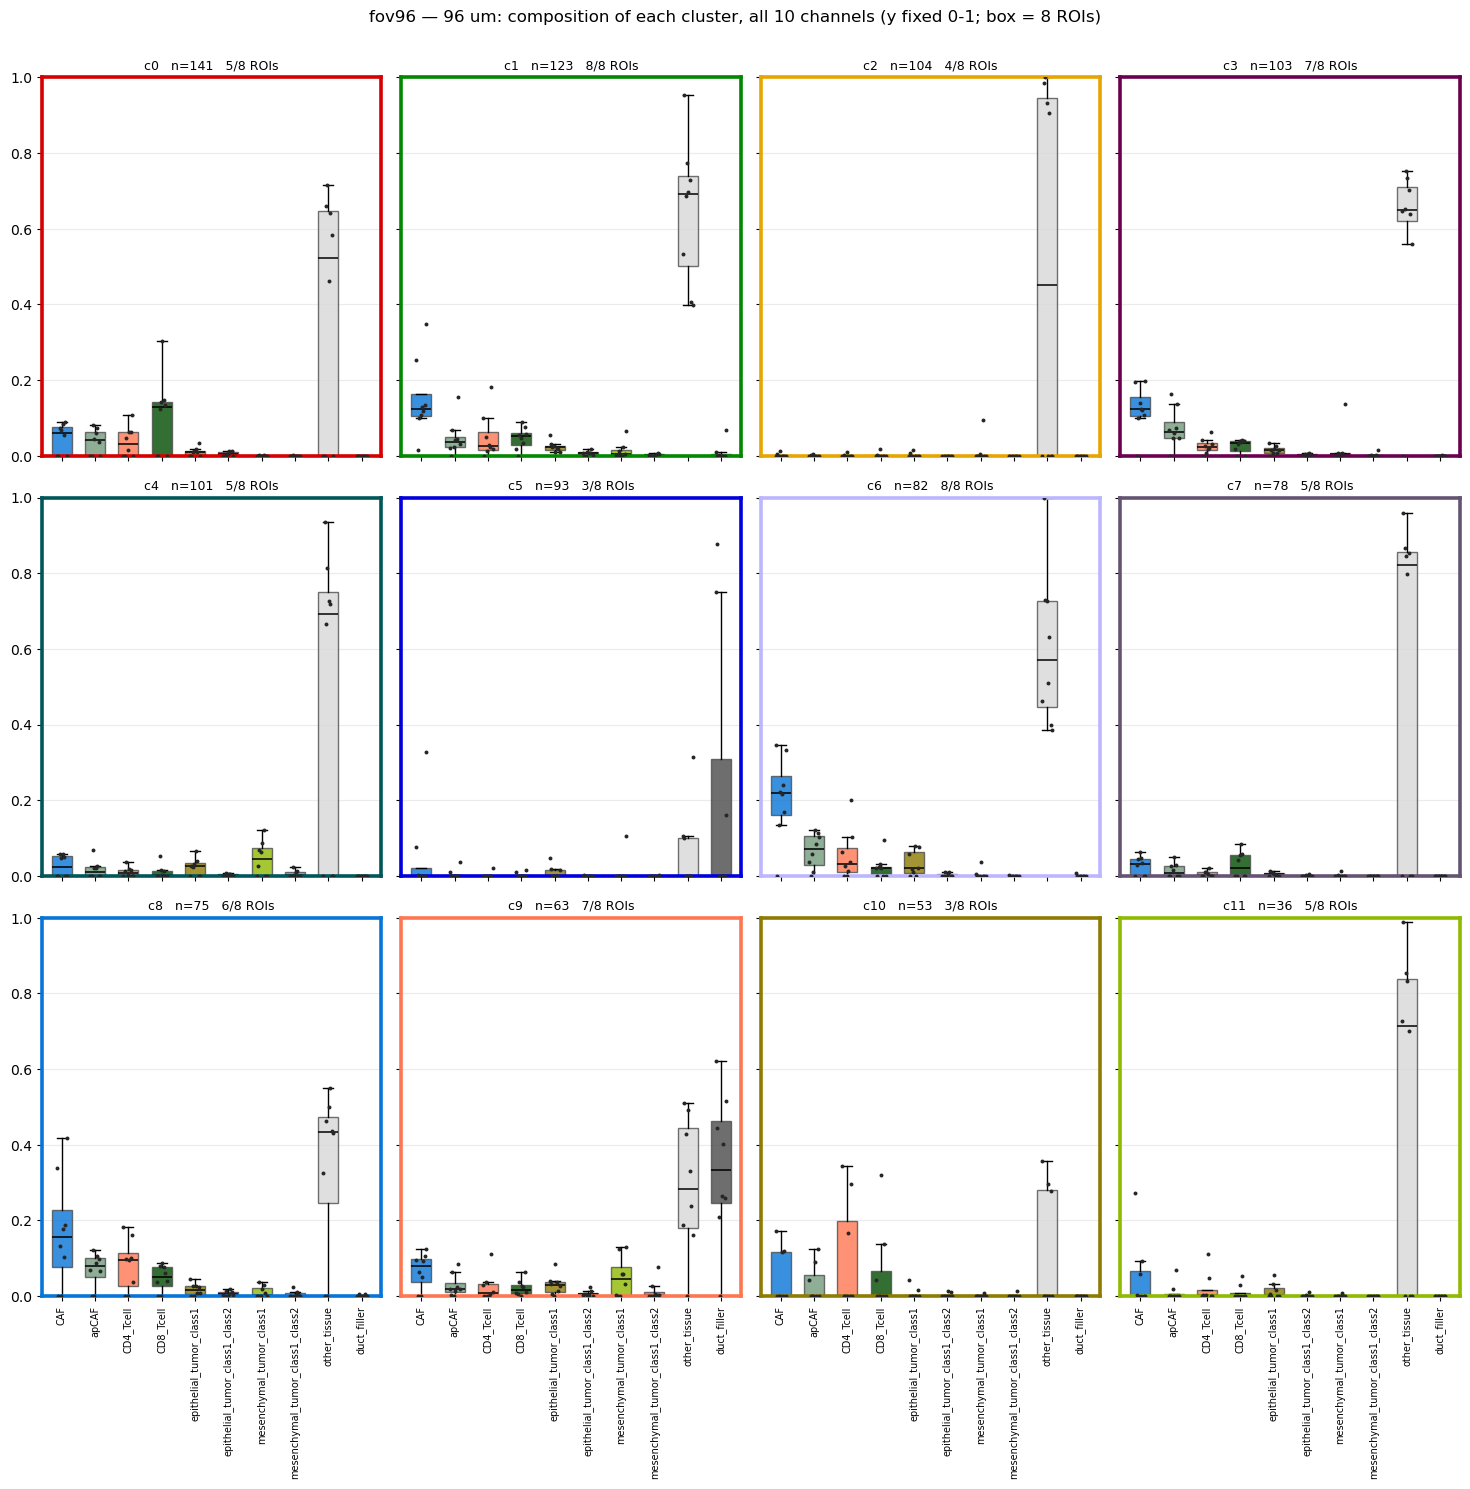

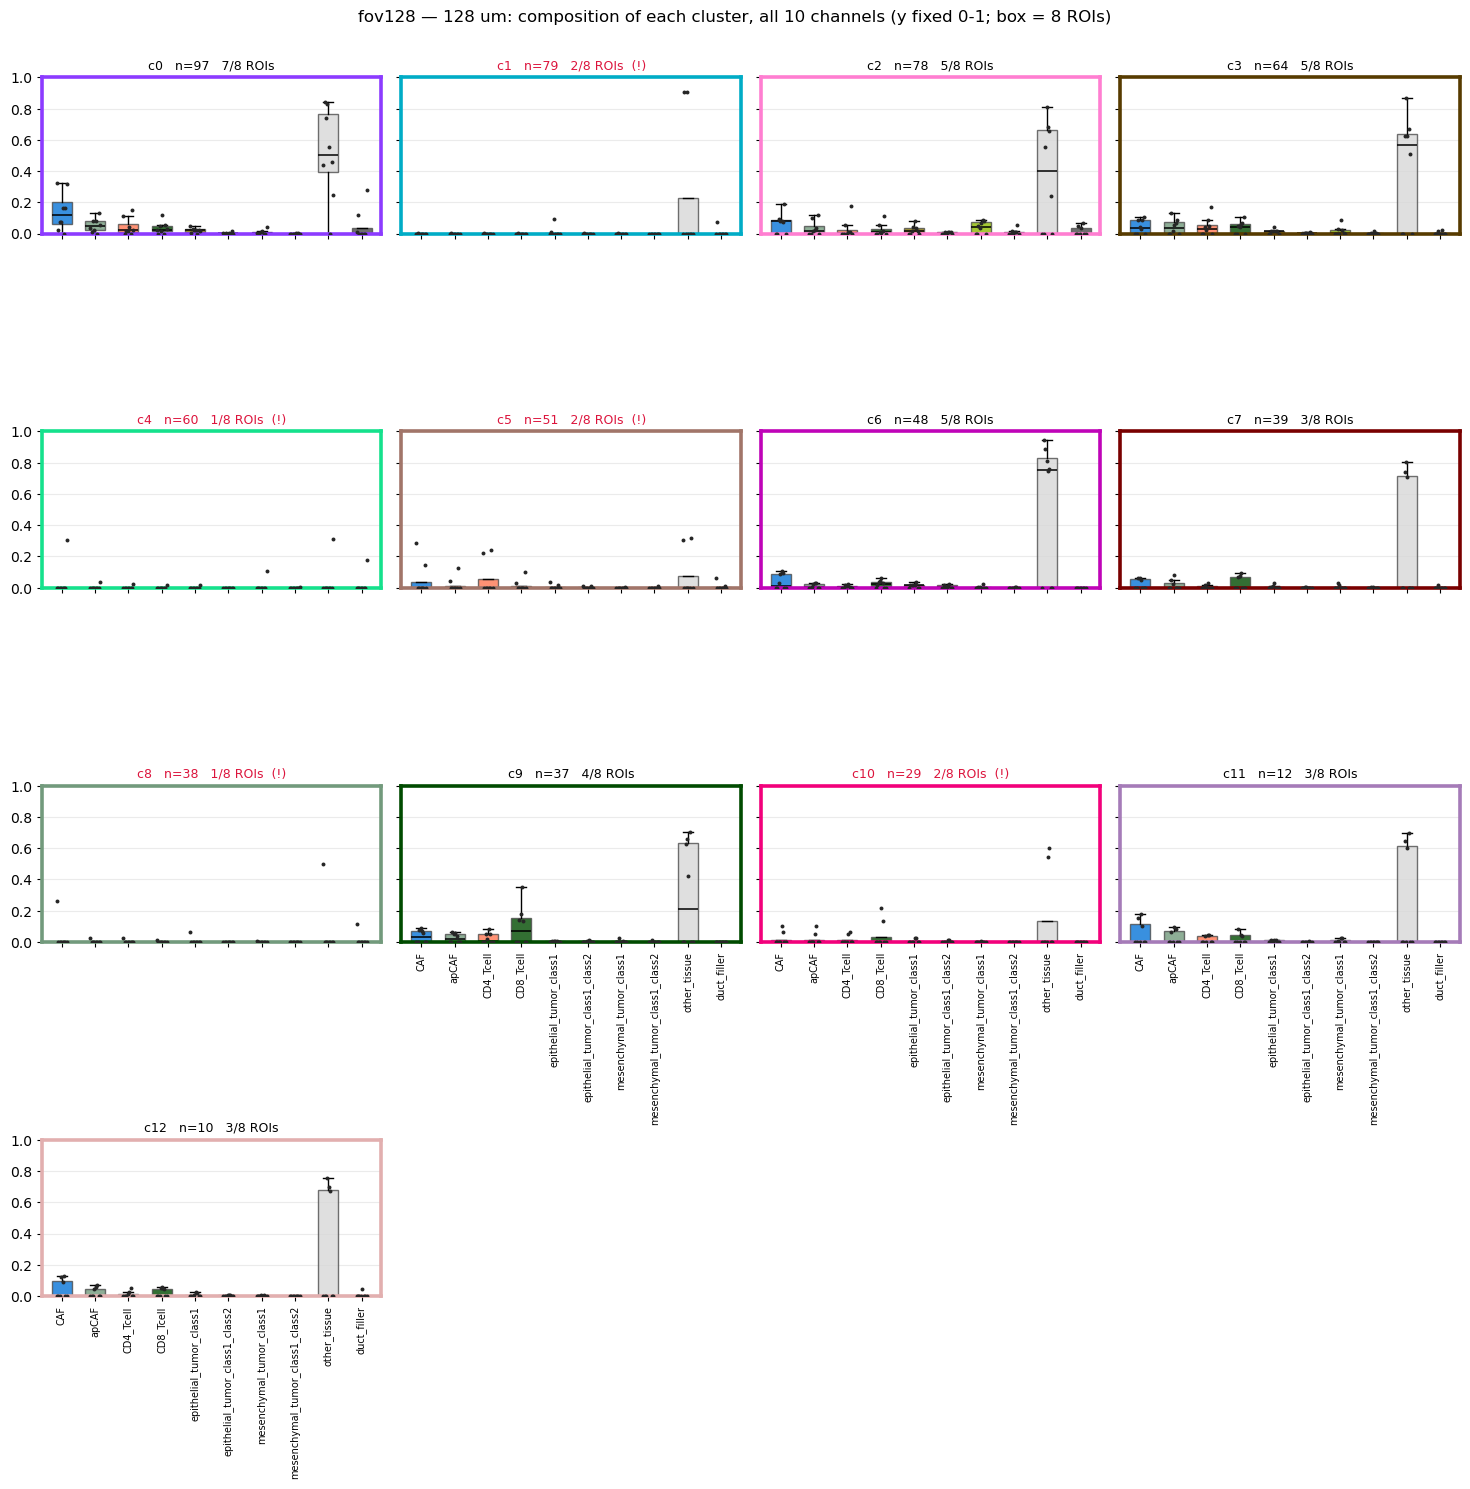

In [12]:
for k in CONFIGS:
    fig = grid_by_cluster(k, imc_tm.CELL_TYPES, 1.0)
    fig.suptitle(
        f"{k} — {CONFIGS[k]} um: composition of each cluster, all 10 channels "
        f"(y fixed 0-1; box = {len(ROIS)} ROIs)",
        y=1.003,
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()

### c2. Cluster per panel, biology types only, y rescaled

Same numbers as c1 — still fractions of **all** cells, background included in the
arithmetic — but the two background types are dropped from the x-axis and the y-axis is
rescaled to the largest biology value across both configs. The eight boxes therefore do
**not** sum to 1; they sum to whatever share of that cluster is classified biology.

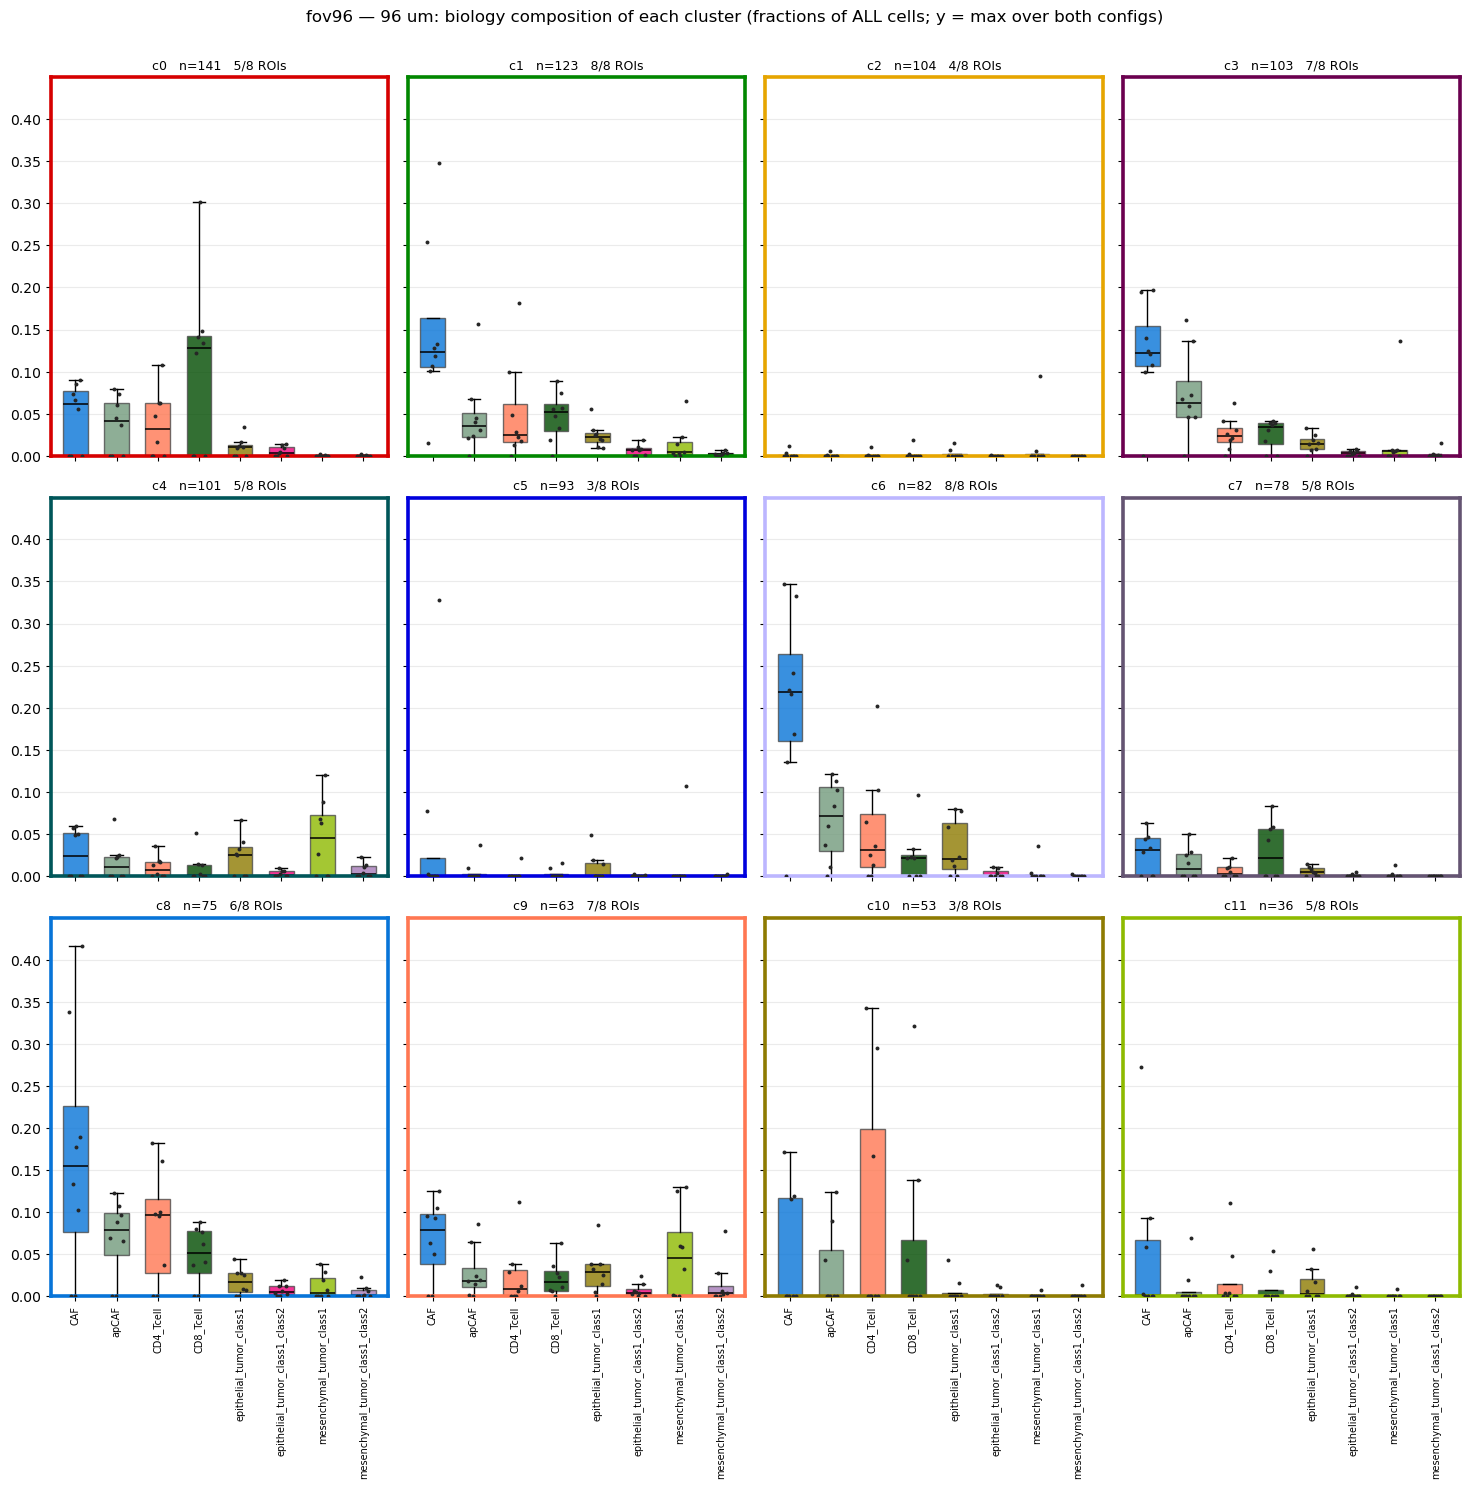

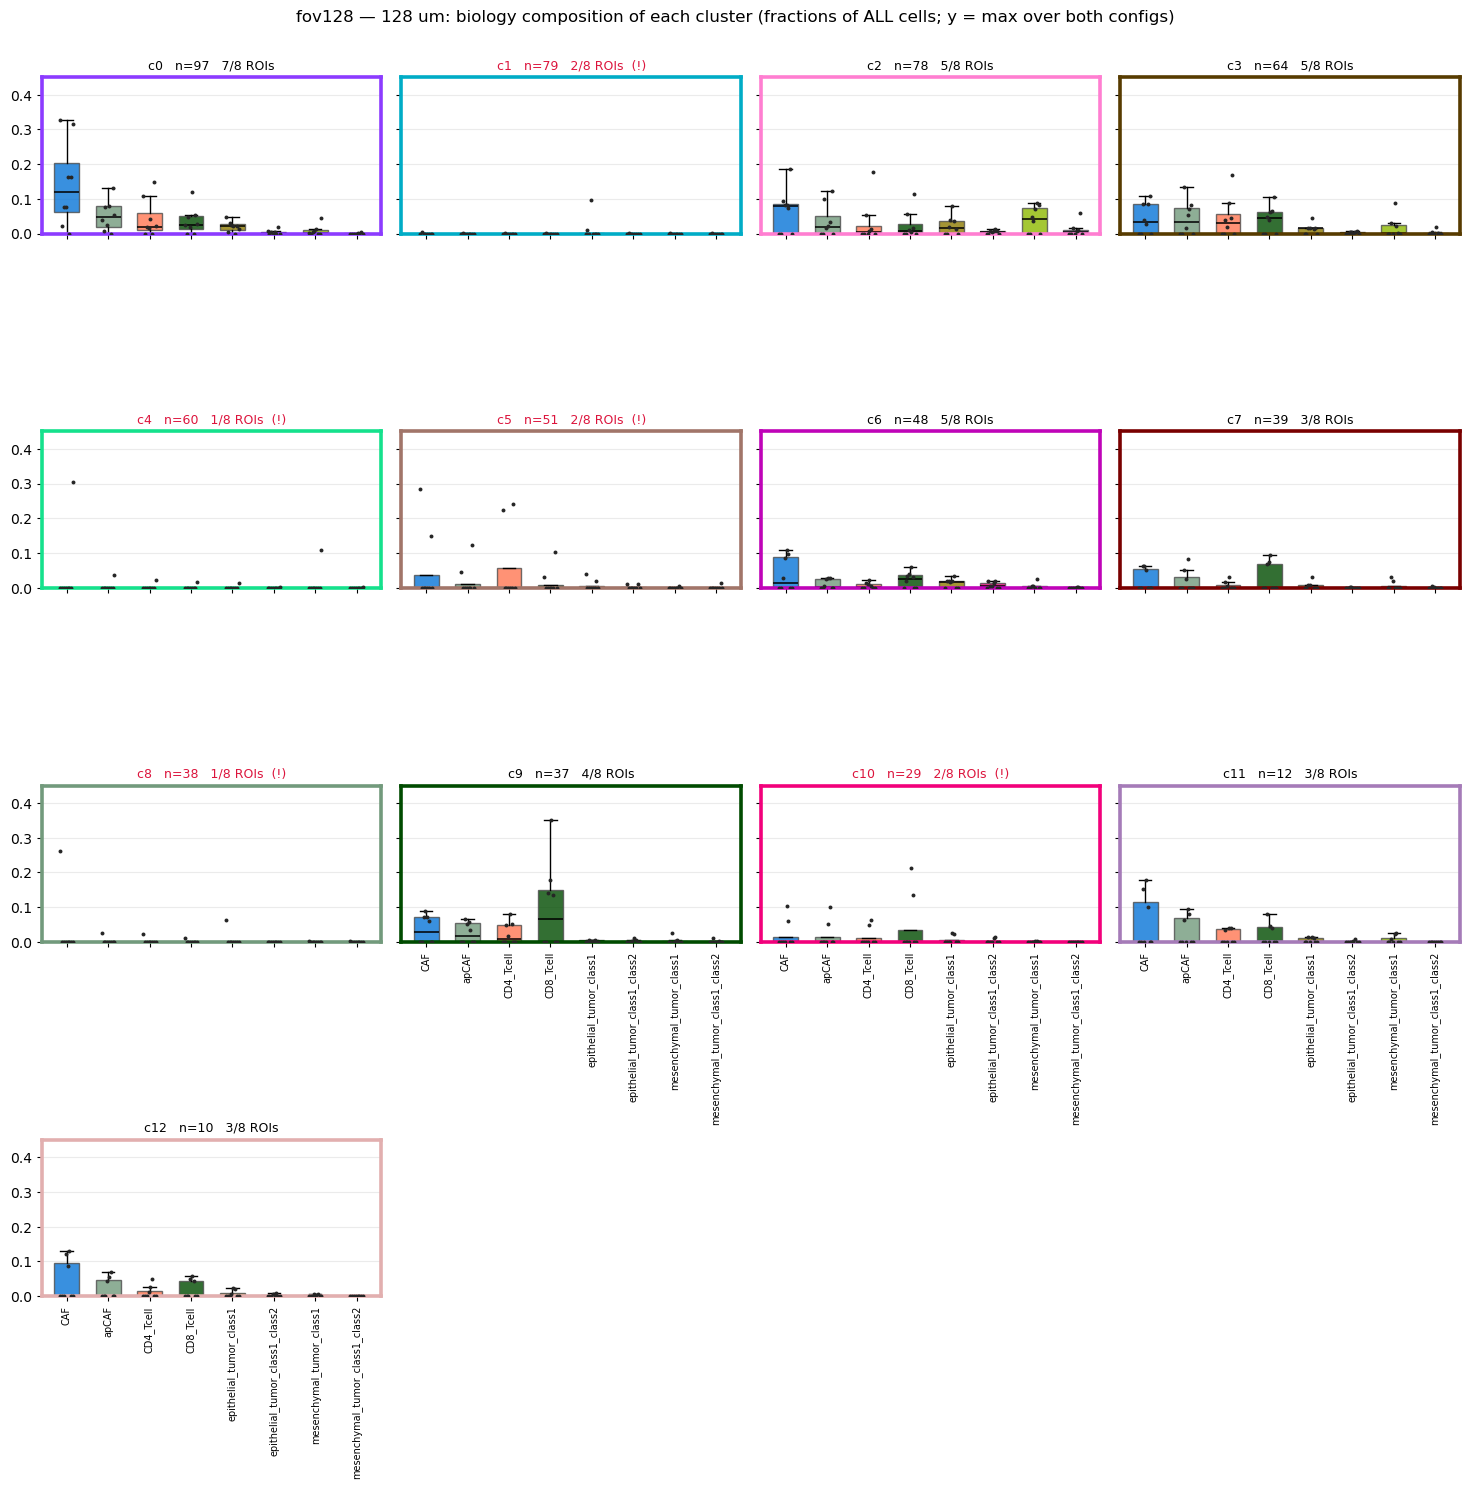

In [13]:
for k in CONFIGS:
    fig = grid_by_cluster(k, imc_tm.BIOLOGY_TYPES, YMAX_BIO)
    fig.suptitle(
        f"{k} — {CONFIGS[k]} um: biology composition of each cluster "
        f"(fractions of ALL cells; y = max over both configs)",
        y=1.003,
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()

## Reading it

- **Tissue maps are the check that depends on no statistic.** Contiguous blocks mean the
  window size resolves real domains; speckle means it does not. Compare each row's window
  panels against its cell panel — a cluster boundary following a visible change in cell
  composition is the model working.
- **UMAP by ROI**: separation by ROI is the failure mode, but some is real biology. Read
  it against S2's composition baseline, not against perfect mixing.
- **Composition spread**: a tight box across ROIs is a recurring motif; a cluster driven
  by one ROI is closer to a section artefact. Section b reads one cell type across all
  clusters; section c reads one cluster's whole profile in a single panel.
- **Border clusters**: at the 10-cell filter expect roughly one cluster per config made
  largely of edge windows — a ring in the tissue maps, and unremarkable composition
  everywhere in the spread plot.

**Caveat: epoch 574 of a planned 1000, and the run stopped at ~600/579.** The cosine
decay (epochs 900–1000) never ran, so neither model has consolidated. Structure visible
here is what the peak-LR plateau produced; it should sharpen if the runs are resumed.